[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MarcoBattiato/PH6721-Deep-Learning-with-Python/blob/main/Classes/Class_5/05A-DistancesAndSVMs.ipynb)

# 05A — Distances, Nearest Neighbours and Support Vector Machines

(by Marco Battiato. For questions/errors/bugs/typos report, please email at marco.battiato.teaching@gmail.com)

**PH6721 — Deep Learning with Python**

**Class 5, Notebook A — Hour 1**

**Instructor:** Marco Battiato (formerly Nanyang Assistant Professor @ Nanyang Technological University)

**email:**  marco.battiato.teaching@gmail.com

**In Person Classes:**  Wednesday 6:30pm - 9:45pm

**Consultation:** remote consultations are to be arranged by writing to marco.battiato.teaching@gmail.com

Class 4 was about trees, and a tree never compares two samples with each other. It asks one
question about one feature at a time — *is the petal longer than 4.8 cm?* — and that is why `04A`
§11.1 could promise that trees need no scaling, ever.

Class 5 starts from the opposite idea: **two samples are similar if they are close**. Closeness is a
distance, and a distance adds up differences in every feature at once — millimetres, degrees and
ratios in the same sum. So the first thing this notebook shows is that the scaling trees could
ignore now decides the answer.

Two methods are built on the idea. **k-nearest neighbours** classifies a sample by asking its
neighbours. **Support vector machines** draw the boundary that keeps the classes as far apart as
possible, and they turn out to be `02B`'s logistic regression with an L2 penalty (`03C`) and a
different loss. That also
settles a promise from `03A` §8: SVM scores are distances, not probabilities.

## Learning Objectives

By the end of this notebook, students should be able to:

- compute a **Euclidean distance** and explain why distance-based methods need their features
  **scaled**, where trees did not;
- name the common alternatives — Manhattan and Chebyshev distance — and say why the default
  exponent is the one to keep;
- explain **k-nearest neighbours**, and recognise $k$ as a flexibility dial that runs the opposite
  way to depth;
- describe the **maximal-margin** classifier and its **support vectors**, and show that only they
  set the boundary;
- explain the **soft margin** and what the hyperparameter `C` controls;
- write the SVM as a **loss plus a penalty** — the **hinge loss** — and compare it with logistic
  regression's;
- write a fitted SVM's score as a sum over its **support vectors**, the form `05B` needs;
- explain why an SVM's scores are **distances, not probabilities**, and how they can be turned into
  probabilities;
- apply the seven-step closing procedure to a nearest-neighbour classifier.

The optional subsection of section **1.2**, section **3.4**, and the subsection **"what separates
the two, once the penalty is the same"** in
section 3.6 are **optional**. The first shows what the Minkowski exponent does to a neighbourhood
as the number of features grows, and why the literature nevertheless gives no reason to move off
the default; the second derives the algorithm behind the support vectors that section 3.3 simply
names; the third answers the question the hinge loss invites — whether an SVM is only logistic
regression with a different loss. Both are the mathematics behind statements the
core sections make and use, and nothing later in the course depends on either.

## Where this sits in the pipeline

The same map as Class 4. Step 7 changes again, and step 5 comes back to life: the scaler that trees
made pointless is now required.

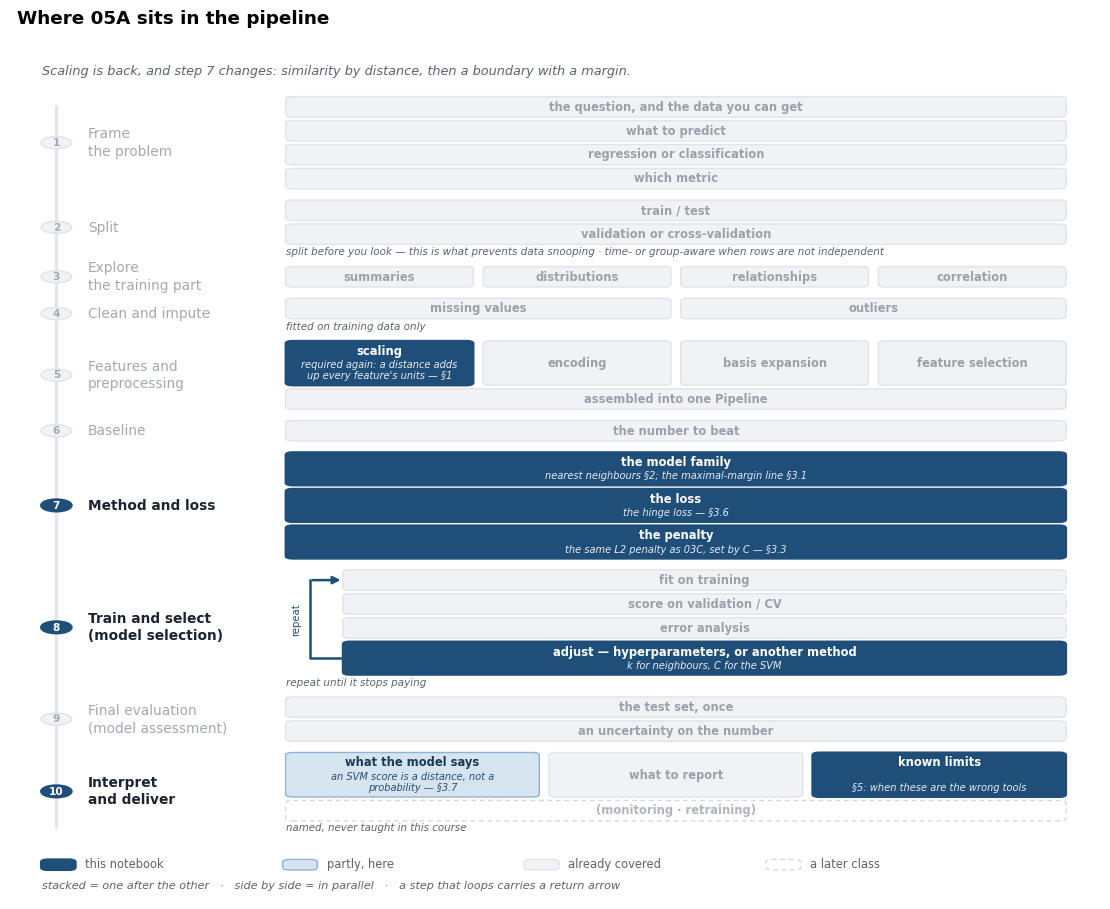

In [ ]:
# Infrastructure, not material. The map below is drawn by one helper file kept with
# the course; Colab has no copy of the repository, so fetch it when it is not already here.
import os, sys, urllib.request
import matplotlib.pyplot as plt

for folder in (".", "..", "../.."):
    if os.path.exists(f"{folder}/pipeline_map.py"):
        sys.path.insert(0, folder)
        break
else:
    urllib.request.urlretrieve("https://raw.githubusercontent.com/MarcoBattiato/"
                               "PH6721-Deep-Learning-with-Python/main/pipeline_map.py",
                               "pipeline_map.py")
from pipeline_map import pipeline_map

pipeline_map(
    {"1": "done", "2": "done", "3": "done", "4": "done", "5": "done", "5.1": "now",
     "5.after": "done", "6": "done", "7.1": "now", "7.2": "now", "7.3": "now",
     "8.1": "done", "8.2": "done", "8.3": "done", "8.4": "now",
     "9": "done", "10.1": "part", "10.2": "done", "10.3": "now"},
    notes={"5.1": "required again: a distance adds up every feature's units — §1",
           "7.1": "nearest neighbours §2; the maximal-margin line §3.1",
           "7.2": "the hinge loss — §3.6",
           "7.3": "the same L2 penalty as 03C, set by C — §3.3",
           "8.4": "k for neighbours, C for the SVM",
           "10.1": "an SVM score is a distance, not a probability — §3.7",
           "10.3": "§5: when these are the wrong tools"},
    title="Where 05A sits in the pipeline",
    lead="Scaling is back, and step 7 changes: similarity by distance, then a boundary with a margin.")
plt.show()

**The step worth remembering is 5.1.** From here to the end of the course — kernels, clustering,
dimensionality reduction, neural networks — almost every method measures distances or takes steps
through a space of features. Trees were the exception.

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from sklearn.datasets import fetch_openml
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score

plt.rcParams.update({
    "figure.dpi": 110, "figure.autolayout": True, "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 12,
    "axes.labelsize": 12, "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False, "legend.fontsize": 10,
})

rng = np.random.default_rng(0)
gamma_colour, hadron_colour = "tab:orange", "tab:blue"

# 1. Similarity is a distance

The most natural way to say that two samples are alike is to say that they are **close**. With $p$
features, each sample is a point in a $p$-dimensional space, and the ordinary — **Euclidean** —
distance between two of them is Pythagoras in $p$ dimensions:

$$
d(\mathbf{x}, \mathbf{x}') \;=\; \sqrt{\sum_{j=1}^{p} \big(x_j - x'_j\big)^2 } .
$$

Every feature contributes the square of its own difference, **in its own units**, and the terms are
simply added. Nothing in the formula knows that one feature is a length in millimetres and another
a ratio between 0 and 1. That is the whole problem of this section.

**The data.** The rest of this notebook uses a table from gamma-ray astronomy (Bock et al., 2004). A
Cherenkov telescope on the ground photographs the faint flash of light that a particle shower makes
in the upper atmosphere. Showers started by **gamma rays** from a source are the signal; showers
started by cosmic-ray **hadrons** are the background, and far more common. Each flash leaves an
image on the telescope's camera, roughly an ellipse, and ten numbers describe it — the ellipse's
length and width in millimetres (the spread of the light along its two axes), the logarithm of its
total light, how concentrated that light is, the angle between its long axis and the direction of
the camera centre, where the source is, and so on. Gamma showers tend to give narrow ellipses
pointing at the centre; hadron showers broader, messier ones.

The 19,020 events were **simulated** with the Monte Carlo program CORSIKA, which is how such
telescopes are trained: the true particle is known only for simulated showers.

> The data come from OpenML. The first run downloads them, which can take a minute or more.

In [ ]:
magic = fetch_openml(data_id=1120, as_frame=True, parser="auto")
X_magic = magic.data.rename(columns=lambda name: name.rstrip(":"))   # OpenML's names end in ":"
y_magic = (magic.target == "g").astype(int)                          # 1 = gamma, 0 = hadron

units = {"fLength": "mm", "fWidth": "mm", "fSize": "log10(photons)", "fConc": "ratio",
         "fConc1": "ratio", "fAsym": "mm", "fM3Long": "mm", "fM3Trans": "mm",
         "fAlpha": "degrees", "fDist": "mm"}

# Split first (02C §6); stratify, because this is classification.
X_train, X_test, y_train, y_test = train_test_split(X_magic, y_magic, test_size=0.25,
                                                    random_state=0, stratify=y_magic)
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

print(f"{len(y_magic)} events: {y_magic.sum()} gamma, {(1 - y_magic).sum()} hadron;"
      f" {len(y_train)} for training, {len(y_test)} for testing\n")
print(f"{'feature':10}{'unit':>16}{'mean':>10}{'std':>10}")
for name in X_train.columns:
    print(f"{name:10}{units[name]:>16}{X_train[name].mean():10.2f}{X_train[name].std():10.2f}")

19020 events: 12332 gamma, 6688 hadron; 14265 for training, 4755 for testing

feature               unit      mean       std
fLength                 mm     53.26     42.61
fWidth                  mm     22.22     18.35
fSize       log10(photons)      2.83      0.48
fConc                ratio      0.38      0.18
fConc1               ratio      0.21      0.11
fAsym                   mm     -4.33     59.61
fM3Long                 mm     10.25     50.98
fM3Trans                mm      0.23     20.81
fAlpha             degrees     27.59     26.06
fDist                   mm    193.72     74.46


The standard deviations run from 74.5 mm for `fDist` down to 0.11 for `fConc1`, a factor of almost
seven hundred. In a distance, that factor is squared.

**How much of a distance does each feature make up?** For two events drawn at random, the average
squared difference in one feature is twice that feature's variance. So each feature's share of the
squared distance is its share of the total variance, and the cell below prints it.

In [ ]:
share = X_train.var() / X_train.var().sum()
print("share of the squared distance between two random events, by feature:\n")
for name, value in share.sort_values(ascending=False).items():
    print(f"   {name:10}{units[name]:>16}   {value:8.3%}")

share of the squared distance between two random events, by feature:

   fDist                   mm    37.059%
   fAsym                   mm    23.749%
   fM3Long                 mm    17.372%
   fLength                 mm    12.134%
   fAlpha             degrees     4.540%
   fM3Trans                mm     2.894%
   fWidth                  mm     2.251%
   fSize       log10(photons)     0.002%
   fConc                ratio     0.000%
   fConc1               ratio     0.000%


Four features measured in millimetres — `fDist`, `fAsym`, `fM3Long` and `fLength` — make up 90% of
the squared distance between two typical events. The total light, `fSize`, and both concentration
ratios together make up less than
a hundredth of a percent. As far as a raw distance is concerned, **they do not exist** — and `fSize`
is one of the quantities astronomers use to tell the showers apart.

Nothing about the physics decided this. The units did. Measure `fDist` in metres instead of
millimetres and it would vanish from the distance as completely as `fSize` has.

## 1.1 Units decide who your neighbours are

The picture makes it concrete. Take two features only, the ellipse's length `fLength` (standard
deviation 42.6 mm) and its concentration `fConc` (0.18), and one imaginary event at 60 mm and 0.35.
Which 40 training events are closest to it?

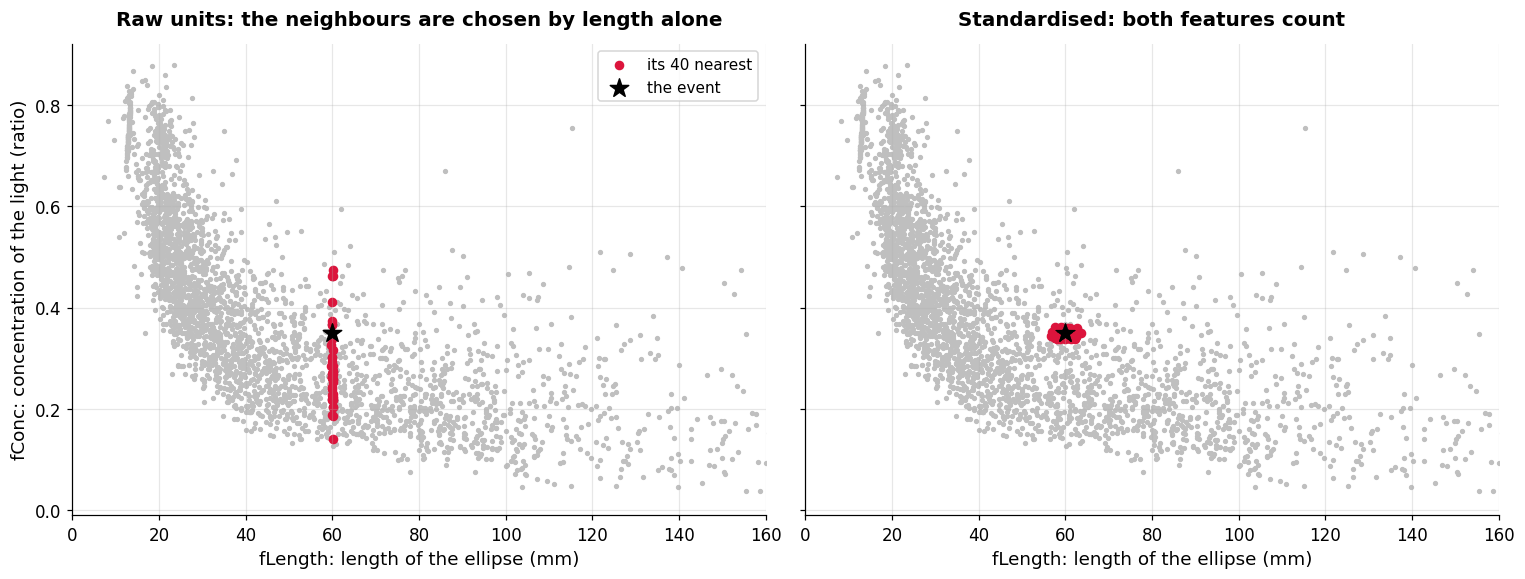

range covered by the 40 neighbours:
   raw           fLength   59.8 to   60.2 mm   fConc 0.14 to 0.47
   standardised  fLength   56.8 to   63.6 mm   fConc 0.34 to 0.36


In [ ]:
pair = ["fLength", "fConc"]
background = X_train[pair].sample(3000, random_state=0)
query = pd.DataFrame({"fLength": [60.0], "fConc": [0.35]})

raw_neighbours = NearestNeighbors(n_neighbors=40).fit(X_train[pair])
_, raw_rows = raw_neighbours.kneighbors(query)

scaler = StandardScaler().fit(X_train[pair])
scaled_neighbours = NearestNeighbors(n_neighbors=40).fit(scaler.transform(X_train[pair]))
_, scaled_rows = scaled_neighbours.kneighbors(scaler.transform(query))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.4), sharex=True, sharey=True)
for axis, rows, title in [(axes[0], raw_rows[0], "Raw units: the neighbours are chosen by length alone"),
                          (axes[1], scaled_rows[0], "Standardised: both features count")]:
    axis.scatter(background["fLength"], background["fConc"], s=6, color="0.75")
    chosen = X_train[pair].iloc[rows]
    axis.scatter(chosen["fLength"], chosen["fConc"], s=28, color="crimson", label="its 40 nearest")
    axis.scatter(query["fLength"], query["fConc"], s=160, marker="*", color="black", zorder=3,
                 label="the event")
    axis.set_title(title)
    axis.set_xlabel("fLength: length of the ellipse (mm)")
    axis.set_xlim(0, 160)
axes[0].set_ylabel("fConc: concentration of the light (ratio)")
axes[0].legend(loc="upper right")
plt.show()

spread = lambda rows: X_train[pair].iloc[rows].agg(["min", "max"])
print("range covered by the 40 neighbours:")
for label, rows in [("raw", raw_rows[0]), ("standardised", scaled_rows[0])]:
    r = spread(rows)
    print(f"   {label:13} fLength {r.loc['min', 'fLength']:6.1f} to {r.loc['max', 'fLength']:6.1f} mm"
          f"   fConc {r.loc['min', 'fConc']:.2f} to {r.loc['max', 'fConc']:.2f}")

On the left, the 40 "nearest" events form a thin vertical stripe: their lengths all lie between
59.8 and 60.2 mm, and their concentrations run from 0.14 to 0.47. A difference of 0.3 in `fConc` —
about half
the range most events occupy — costs as much as a difference of 0.3 mm in length, which is
nothing. On the right,
after each feature is divided by its standard deviation, the neighbours form a compact patch around
the event in both directions: 56.8 to 63.6 mm, and 0.34 to 0.36.

**Does it matter for prediction?** The cell below classifies every event by the 15 training events
nearest to it — the method of section 2 — with all ten features, first in raw units and then
standardised. Scaling goes inside a pipeline so that it is learned from the training folds only
(`02C` §6.3). The score is ROC AUC (`03A` §7), which measures how well the events are *ranked*
without fixing a
threshold. The dataset's authors warn that accuracy is not meaningful here, because calling a hadron
a gamma is much worse than the reverse, and ask for the ROC curve itself; section 7 looks at the
points of it they single out.

In [ ]:
for label, model in [("raw units", KNeighborsClassifier(n_neighbors=15)),
                     ("standardised", make_pipeline(StandardScaler(),
                                                    KNeighborsClassifier(n_neighbors=15)))]:
    scores = cross_val_score(model, X_train, y_train, cv=folds, scoring="roc_auc")
    print(f"15 nearest neighbours, {label:13}: ROC AUC {scores.mean():.3f} +/- {scores.std():.3f}")

15 nearest neighbours, raw units    : ROC AUC 0.854 +/- 0.006


15 nearest neighbours, standardised : ROC AUC 0.897 +/- 0.004


Scaling raises the ROC AUC from 0.854 to 0.897, about eight times the fold spread. Nothing else
changed: same neighbours rule, same data, same folds. The raw version was working with seven
features instead of ten, and chose which seven by their units.

> **Any method that measures distances needs its features on comparable scales.** This is the exact
> inversion of `04A` §11.1: a tree asks about one feature at a time, so units never meet; a
> distance adds them up. Standardising — subtracting the mean and dividing by the standard
> deviation, inside a pipeline — is the default. It is a choice, not a law: it says "one standard
> deviation of every feature counts equally", and a physicist who knows that some feature matters
> more may weight it more. Standardising also rescales each feature on its own; the **Mahalanobis**
> distance, familiar from $\chi^2$, undoes the correlations between them as well.

## 1.2 Other ways to measure distance

Euclidean distance is one member of a family. The **Minkowski** distance with exponent $q$ is

$$
d_q(\mathbf{x}, \mathbf{x}') \;=\; \Big(\sum_{j=1}^{p} \big|x_j - x'_j\big|^q\Big)^{1/q},
$$

and three values of $q$ have names. $q = 2$ is Euclidean. $q = 1$ is the **Manhattan** distance,
the sum of the absolute differences — the distance a taxi drives on a grid of streets. And as $q$
grows, the largest single difference takes over, giving the **Chebyshev** distance: how far apart
the two samples are in the one feature where they differ most. In `scikit-learn` the choice is the
`metric` argument of the neighbour methods — `"minkowski"` by default, with `p=1` or `p=2` for the
first two, and `"chebyshev"` for the third.

**The practical advice is short: leave it at $q = 2$.** That is not laziness. Benchmarks across
 dozens of
classification problems find $q = 0.5$, $q = 1$ and $q = 2$ statistically indistinguishable, and
the standard texts barely discuss the family at all — they simply take distances to be Euclidean.
Compare that with the effect of **scaling** in section
1.1 — 0.854 to 0.897 from one line of code — and the ranking of what deserves your attention is
clear. What no exponent can do is repair unscaled features, since every one of them adds or
compares raw differences.

One more measure of similarity belongs to later classes: the **cosine similarity**, the cosine of
the angle between two vectors regardless of their lengths, which is how learned representations are
compared in Class 9.

The metric returns in `05C`, where clustering groups samples by their distances, and in Class 6,
where t-SNE and UMAP draw maps built from them — maps that keep each sample's neighbours near it,
without preserving the distances themselves.

### Optional: what the exponent actually changes

The rest of this section shows *why* the advice above is what it is, and nothing later depends on
it. It is worth reading once, because it ends in a warning that generalises far beyond metrics.

The clearest way to see what $q$ does is to draw every point at distance 1 from the origin.

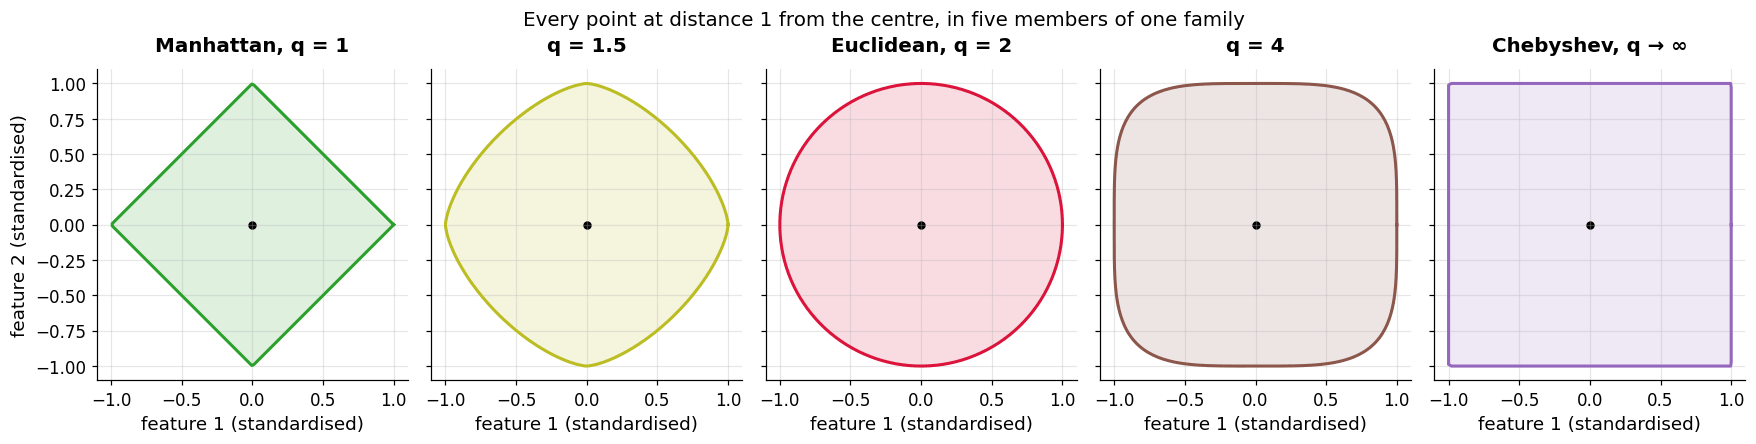

In [ ]:
angle = np.linspace(0, 2 * np.pi, 400)
fig, axes = plt.subplots(1, 5, figsize=(16, 3.8), sharex=True, sharey=True)
for axis, (name, q, colour) in zip(axes, [("Manhattan, q = 1", 1, "tab:green"),
                                          ("q = 1.5", 1.5, "tab:olive"),
                                          ("Euclidean, q = 2", 2, "crimson"),
                                          ("q = 4", 4, "tab:brown"),
                                          ("Chebyshev, q → ∞", np.inf, "tab:purple")]):
    direction = np.column_stack([np.cos(angle), np.sin(angle)])
    length = np.linalg.norm(direction, ord=q, axis=1)       # distance of each direction, in this metric
    unit = direction / length[:, None]                      # rescaled so every point is at distance 1
    axis.fill(unit[:, 0], unit[:, 1], color=colour, alpha=0.15)
    axis.plot(unit[:, 0], unit[:, 1], color=colour, linewidth=2)
    axis.scatter([0], [0], color="black", s=20)
    axis.set_title(name)
    axis.set_aspect("equal")
    axis.set_xlabel("feature 1 (standardised)")
axes[0].set_ylabel("feature 2 (standardised)")
fig.suptitle("Every point at distance 1 from the centre, in five members of one family",
             fontsize=13)
plt.show()

The Euclidean "circle" is a circle. The Manhattan one is a diamond: moving diagonally costs more,
because both differences are paid in full. The Chebyshev one is a square: only the larger difference
counts. The two in between show that the family is continuous: the shape swells steadily from the
diamond to the square as $q$ grows, and every intermediate value is a legitimate metric. What $q$
sets is **how much one large difference is allowed to dominate the rest** — at $q = 1$ it is merely
added in, and as $q \to \infty$ it is the only thing that counts.

**Now the same choice, in ten dimensions rather than two.** Those five pictures are
two-dimensional, and they make the choice of $q$ look like a mild change of shape. It is not. The
honest way to see the difference is to ask how much **room** each of these
unit balls actually encloses as the number of features grows — how big "within distance 1" is,
compared with the box $[-1, 1]^p$ that just contains it.

For the Minkowski-$q$ ball there is a closed form, and the ratio to that box is

$$
\frac{\text{volume of the unit } q \text{-ball}}{\text{volume of the box}}
\;=\; \frac{\Gamma(1 + 1/q)^p}{\Gamma(1 + p/q)} ,
$$

which is 1 for the Chebyshev ball, because there the ball **is** the box.

In [ ]:
from scipy.special import gammaln            # log of the gamma function, for numbers this small

def ball_over_cube(q, p):
    """Volume of the unit Minkowski-q ball divided by the volume of the cube [-1, 1]^p."""
    return np.exp(p * gammaln(1 + 1 / q) - gammaln(1 + p / q))

# Two cases the reader can check by hand, to show the formula is the right one.
print(f"p = 2, q = 2: {ball_over_cube(2, 2):.6f}   a disc in a square, pi/4 = {np.pi / 4:.6f}")
print(f"p = 2, q = 1: {ball_over_cube(1, 2):.6f}   a diamond in a square, 1/2")

exponents = [1, 1.5, 2, 4]
print(f"\n{'features p':>11}" + "".join(f"{'q = ' + str(q):>13}" for q in exponents) + f"{'q -> inf':>11}")
for p in [2, 3, 5, 10, 20, 50]:
    print(f"{p:>11}" + "".join(f"{ball_over_cube(q, p):>13.2e}" for q in exponents) + f"{1.0:>11.2f}")

print(f"\nwith p = 10, a corner of the box lies {np.sqrt(10):.2f} times further from the centre"
      f"\nthan the surface of the Euclidean ball that just fits inside it")

p = 2, q = 2: 0.785398   a disc in a square, pi/4 = 0.785398
p = 2, q = 1: 0.500000   a diamond in a square, 1/2

 features p        q = 1      q = 1.5        q = 2        q = 4   q -> inf
          2     5.00e-01     6.84e-01     7.85e-01     9.27e-01       1.00
          3     1.67e-01     3.68e-01     5.24e-01     8.10e-01       1.00
          5     8.33e-03     6.47e-02     1.64e-01     5.40e-01       1.00
         10     2.76e-07     1.39e-04     2.49e-03     1.13e-01       1.00
         20     4.11e-19     8.68e-12     2.46e-08     1.17e-03       1.00
         50     3.29e-65     2.14e-40     1.54e-28     4.29e-12       1.00

with p = 10, a corner of the box lies 3.16 times further from the centre
than the surface of the Euclidean ball that just fits inside it


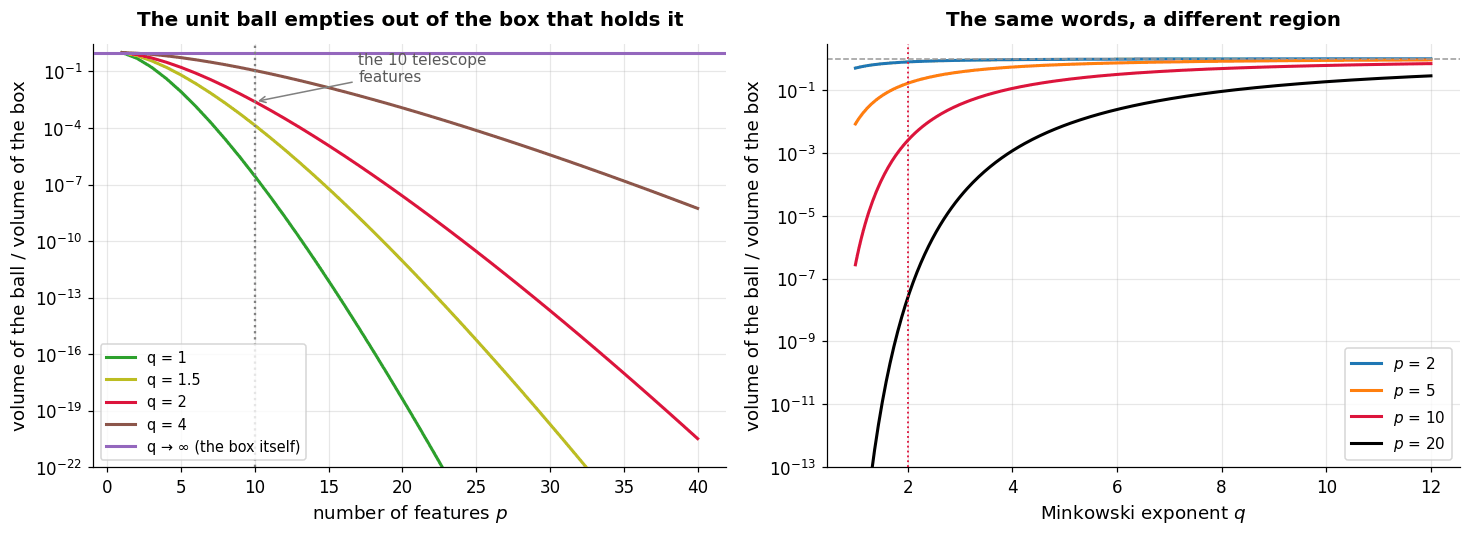

In [ ]:
features = np.arange(1, 41)
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))

for q, colour in [(1, "tab:green"), (1.5, "tab:olive"), (2, "crimson"), (4, "tab:brown")]:
    axes[0].semilogy(features, ball_over_cube(q, features), color=colour, linewidth=2, label=f"q = {q}")
axes[0].axhline(1, color="tab:purple", linewidth=2, label="q → ∞ (the box itself)")
axes[0].axvline(10, color="0.5", linestyle=":", linewidth=1.5)
axes[0].annotate("the 10 telescope\nfeatures", xy=(10, 2.5e-3), xytext=(17, 3e-2), fontsize=10,
                 color="0.35", arrowprops={"arrowstyle": "->", "color": "0.5"})
axes[0].set(xlabel="number of features $p$", ylabel="volume of the ball / volume of the box",
            title="The unit ball empties out of the box that holds it", ylim=(1e-22, 3))
axes[0].legend(loc="lower left", fontsize=9.5)

exponents_fine = np.linspace(1, 12, 300)
for p, colour in [(2, "tab:blue"), (5, "tab:orange"), (10, "crimson"), (20, "black")]:
    axes[1].semilogy(exponents_fine, ball_over_cube(exponents_fine, p), color=colour, linewidth=2,
                     label=f"$p$ = {p}")
axes[1].axvline(2, color="crimson", linestyle=":", linewidth=1.2)
axes[1].axhline(1, color="0.6", linestyle="--", linewidth=1)
axes[1].set(xlabel="Minkowski exponent $q$", ylabel="volume of the ball / volume of the box",
            title="The same words, a different region", ylim=(1e-13, 3))
axes[1].legend(loc="lower right", fontsize=10)
plt.show()

In two dimensions the five metrics are within a factor of two of one another — $\pi/4$ against
$1/2$, exactly the disc and the diamond drawn above. By ten features, the number this course
actually works with, they are not comparable at all: the Euclidean ball holds 0.25% of the box and
the Manhattan ball three parts in ten million. By fifty features they are separated by thirty-seven
orders of magnitude.

None of this is peculiar to the Minkowski family. The same calculation is a standard illustration
of high-dimensional geometry for $q = 2$, alongside a companion fact the cell above prints: a corner
of the box lies $\sqrt{p}$ times further from the centre than a face does — 3.16 at ten features,
10 at a hundred. Almost all of a cube's volume ends up in its corners, which stretch out into long
thin spikes, and almost all of a sphere's volume ends up in a thin shell just under its surface.

So the phrase "within distance 1" names wildly different regions depending on $q$, and the
disagreement grows without limit. In two dimensions the choice of metric is a matter of taste; in
ten it is a matter of orders of magnitude.

**Now the part that is easy to get wrong, and worth more than the picture.** Read the figure
naively and it argues for the *largest* $q$ — the ratio climbs steadily towards the Chebyshev ball,
which wastes no room at all. That conclusion does not follow, and the literature does not draw it.
The volume of a ball is simply not the quantity that governs how nearest neighbours behave: what
matters there is how **spread out** the distances between actual samples are, and a ball's volume
says nothing about that. Not one of the standard papers on choosing a metric in high dimensions
uses a volume anywhere in its argument.

What those papers do say is worth stating plainly, because it is unsettled. Aggarwal, Hinneburg and
Keim (2001) argued that smaller exponents give better contrast between the nearest and furthest
neighbour, and recommended $q = 1$ and even $q < 1$. François, Wertz and Verleysen (2007) then
proved that this holds for uniformly distributed features but **not in general**, with real datasets
as counterexamples. And Mirkes, Allohibi and Gorban (2020) tested thirty-seven classification
problems and found that $q = 0.5$, $q = 1$ and $q = 2$ perform *statistically indistinguishably* —
and, pointedly, that the exponent with the best contrast was among the worst classifiers. Their own
conclusion is that dimensionality reduction and feature selection are far more powerful than
"playing with norms".

> **Take the geometry, not the recommendation.** The collapse above is exact, and it is why a
> neighbourhood in many dimensions stops being local. It is *not* a reason to prefer one $q$: on
> present evidence the exponent is not where the leverage is, and `scikit-learn`'s default of
> $q = 2$ needs no apology. The established remedy for high-dimensional neighbours is to let the
> metric *stretch* in the directions that matter, not to change the exponent — which is §2.3's
> subject.

Two things keep this from being a counsel of despair. Real measurements are usually confined to a
region of much lower effective dimension than the number of
columns suggests, and real relationships are usually smooth. `06A` is where the course takes that
up properly, under its own name — the **curse of dimensionality**.

# 2. k-nearest neighbours

The simplest possible method built on a distance:

1. **Training** is storing the training set. Nothing is fitted.
2. To classify a new sample, find the $k$ training samples **nearest** to it.
3. Predict the class most of them belong to. The fraction of the $k$ that belong to each class is
   the predicted probability.

For regression, step 3 averages the neighbours' targets instead. All the work happens at prediction
time, which is why k-nearest neighbours (kNN) is called a **lazy** method.

## 2.1 What the regions look like

**$k$ is a flexibility dial**, and it runs the opposite way to the dials so far. With $k = 1$ every
training sample decides the region around it on its own, so the boundary follows every
fluctuation. With $k$ equal to the whole training set, every prediction is the overall majority. The
figure uses two features that separate the classes well on their own: the ellipse's length, and its
angle `fAlpha` — small when the ellipse points at the camera centre, which is what the dataset's own
description singles out as the discriminating geometry, since a shower from the source points there
and a cosmic-ray shower has no reason to.

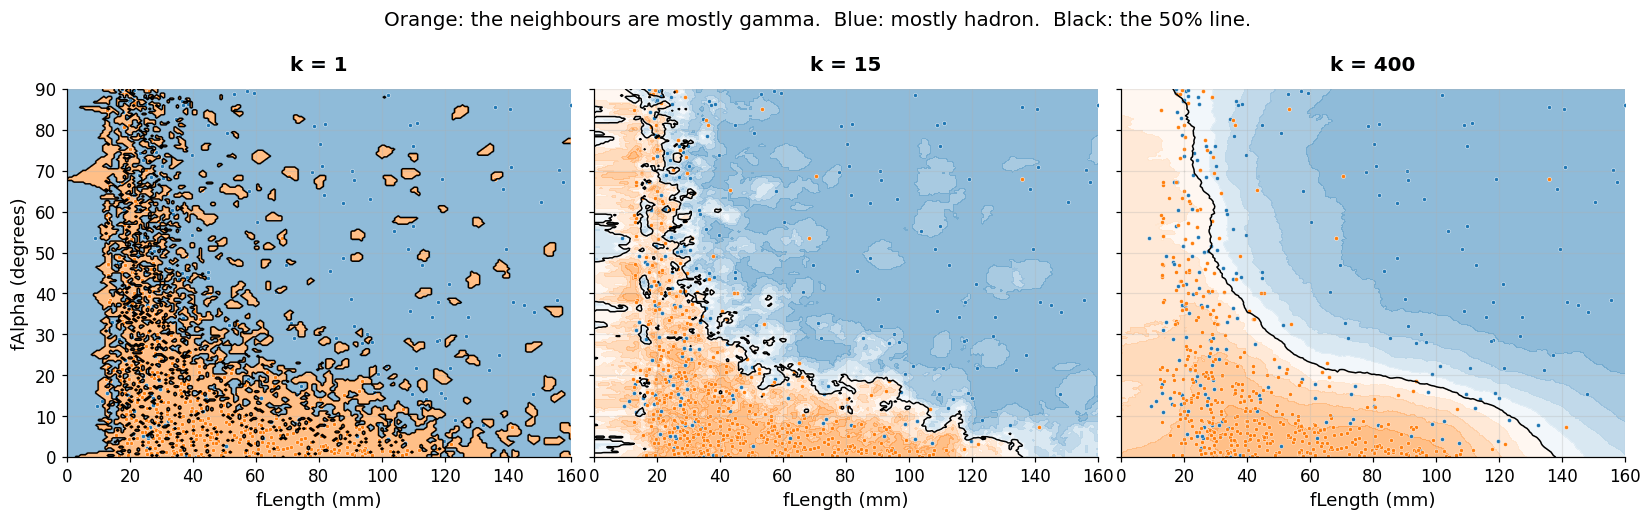

In [ ]:
pair = ["fLength", "fAlpha"]
lengths = np.linspace(0, 160, 220)
alphas = np.linspace(0, 90, 220)
LL, AA = np.meshgrid(lengths, alphas)
mesh = pd.DataFrame({"fLength": LL.ravel(), "fAlpha": AA.ravel()})
shown = X_train.sample(700, random_state=1).index
two_colours = LinearSegmentedColormap.from_list("hadron_gamma", [hadron_colour, "white", gamma_colour])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)
for axis, k in zip(axes, [1, 15, 400]):
    model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    model.fit(X_train[pair], y_train)
    gamma_share = model.predict_proba(mesh)[:, 1].reshape(LL.shape)
    axis.contourf(LL, AA, gamma_share, levels=np.linspace(0, 1, 11), cmap=two_colours, alpha=0.55)
    axis.contour(LL, AA, gamma_share, levels=[0.5], colors="black", linewidths=1)
    for label, colour in [(0, hadron_colour), (1, gamma_colour)]:
        rows = shown[y_train.loc[shown] == label]
        axis.scatter(X_train.loc[rows, "fLength"], X_train.loc[rows, "fAlpha"], s=7,
                     color=colour, edgecolor="white", linewidth=0.3)
    axis.set_title(f"k = {k}")
    axis.set_xlim(0, 160)
    axis.set_xlabel("fLength (mm)")
axes[0].set_ylabel("fAlpha (degrees)")
fig.suptitle("Orange: the neighbours are mostly gamma.  Blue: mostly hadron.  Black: the 50% line.",
             fontsize=13)
plt.show()

With one neighbour the map is confetti: every training event paints its own little island, and the
50% line wanders around individual points. With 15 the islands merge into a clear pattern — gamma
showers are short and point at the centre, bottom left. With 400 the boundary is smooth, and the
region it claims for gamma is smaller: each prediction averages over a neighbourhood so large that
it reaches well into the hadrons.

## 2.2 $k$ is a flexibility dial

The figure above used two features so that it could be drawn. The sweep below goes back to all ten
and asks cross-validation where, between 1 and 400 neighbours, the best $k$ lies. Two questions
first:

1. The cell scores each $k$ on the **training** events as well as by cross-validation. What will the
   training ROC AUC be at $k = 1$?
2. Where will the cross-validated curve peak — at small $k$, large $k$, or in between?

**Think about your answer before running this cell.**

In [ ]:
neighbour_counts = [1, 3, 5, 9, 15, 31, 61, 151, 401]
training_auc, validation_auc = [], []
for k in neighbour_counts:
    model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k)).fit(X_train, y_train)
    training_auc.append(roc_auc_score(y_train, model.predict_proba(X_train)[:, 1]))
    validation_auc.append(cross_val_score(model, X_train, y_train, cv=folds,
                                          scoring="roc_auc").mean())

fig, axis = plt.subplots(figsize=(10, 5))
axis.plot(neighbour_counts, training_auc, "o-", color="0.5", label="on the training events")
axis.plot(neighbour_counts, validation_auc, "o-", color="crimson", label="cross-validated")
axis.set_xscale("log")
axis.set_xticks(neighbour_counts, [str(k) for k in neighbour_counts])
axis.set_xlabel("k, the number of neighbours   (← more flexible)")
axis.set_ylabel("ROC AUC")
axis.set_title("One neighbour memorises; hundreds average the signal away")
axis.legend()
plt.show()

for k, train, valid in zip(neighbour_counts, training_auc, validation_auc):
    print(f"k = {k:4}   training {train:.3f}   cross-validated {valid:.3f}")

**At $k = 1$ the training score is perfect, 1.000**, and it means nothing: every training event is
its own nearest neighbour, so it is always classified correctly. This is `02C`'s memorising model in
its purest form — the method stores the training set and reads it back. The cross-validated score
at $k = 1$ is the worst on the curve, 0.779.

**The cross-validated curve rises, flattens and falls.** It peaks at around 31 neighbours, at 0.900,
and is within 0.003 of that from 15 to 61; by 401 it has fallen back to 0.873. Small $k$ is
high-variance — one unlucky neighbour flips a prediction — and large $k$ is high-bias, because the
neighbourhood grows until it no longer describes the region the sample is in. It is `03B`'s
trade-off, on a dial that points the other way: `04A`'s depth made a tree *more* flexible as it
grew; here flexibility grows as $k$ *shrinks*.

A useful way to line the dials up: with $n$ training samples, kNN behaves like a model with an
**effective** number of parameters of about $n/k$ — one
for each neighbourhood, if the neighbourhoods did not overlap.

## 2.3 One $k$, and a feature space that is not evenly filled

Section 2.2 chose a single $k$ for the whole feature space. That is a stronger assumption than it
looks, because **a fixed number of neighbours does not mean a fixed neighbourhood.**

The standard statement of the problem is about dimension: in a
high-dimensional feature space the nearest neighbours of a point can be very far away, which biases
the rule and degrades it. For uniformly distributed data the median radius of a 1-nearest
neighbourhood grows with dimension until it approaches the distance to the edge of the space
itself — and its remedy is to **adapt the metric**, stretching each neighbourhood in the directions
where the class probabilities change least — the
**DANN** rule of Hastie and Tibshirani.

What follows is the same mechanism — *far neighbours bias the estimate* — arriving from a different
direction, one this course will meet long before it meets fifty dimensions. Where the **sampling
density** varies, the neighbourhood must reach further in the thin regions even when the space is
one-dimensional. The cell shows that case, because it can be drawn: the same curve, the same noise,
and the same 31 neighbours everywhere, with the left half of the range sampled nine times more
densely than the right.

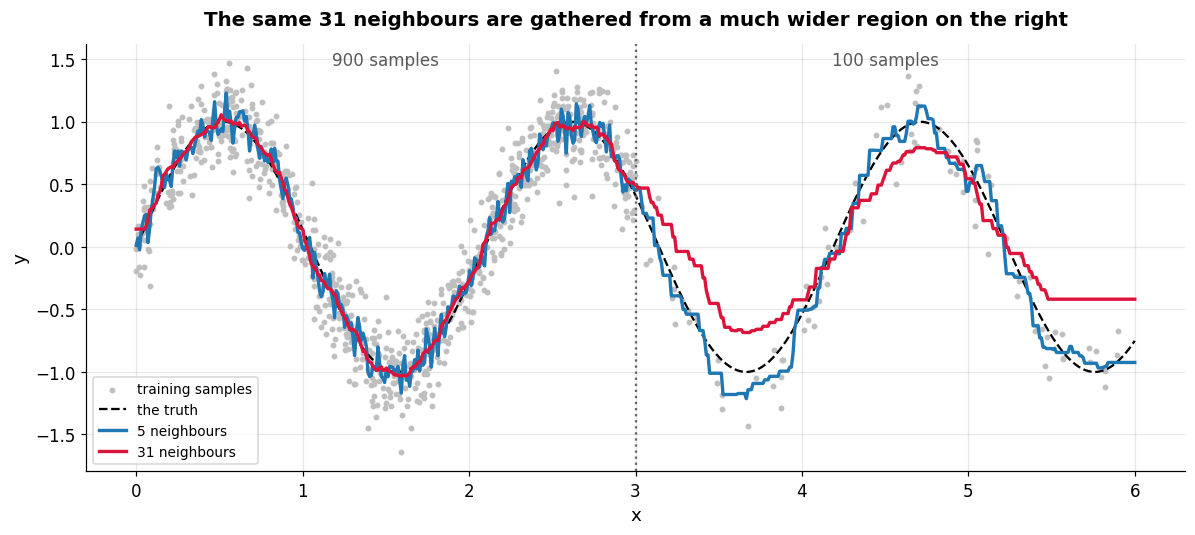

to hold 31 neighbours the window must reach 0.051 on the crowded side and 0.429 on the thin side

                                     crowded side   thin side
RMSE, 5 nearest neighbours                  0.238       0.228
RMSE, 15 nearest neighbours                 0.220       0.217
RMSE, 31 nearest neighbours                 0.214       0.337


RMSE, gradient boosting                     0.225       0.256


In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import HistGradientBoostingRegressor

uneven = np.random.default_rng(0)
curve = lambda t: np.sin(3 * t)

x_train = np.concatenate([uneven.uniform(0, 3, 900), uneven.uniform(3, 6, 100)])   # 9x denser left
y_curve = curve(x_train) + uneven.normal(0, 0.2, len(x_train))
x_check = np.concatenate([uneven.uniform(0, 3, 500), uneven.uniform(3, 6, 500)])
y_check = curve(x_check) + uneven.normal(0, 0.2, len(x_check))
crowded = x_check < 3

grid = np.linspace(0, 6, 600).reshape(-1, 1)
fig, axis = plt.subplots(figsize=(11, 5))
axis.scatter(x_train, y_curve, s=8, color="0.75", label="training samples")
axis.plot(grid, curve(grid.ravel()), "k--", linewidth=1.5, label="the truth")
for k, colour in [(5, "tab:blue"), (31, "crimson")]:
    fitted = KNeighborsRegressor(k).fit(x_train.reshape(-1, 1), y_curve)
    axis.plot(grid, fitted.predict(grid), color=colour, linewidth=2.2, label=f"{k} neighbours")
axis.axvline(3, color="0.4", linestyle=":", linewidth=1.5)
axis.text(1.5, 1.45, "900 samples", ha="center", color="0.35")
axis.text(4.5, 1.45, "100 samples", ha="center", color="0.35")
axis.set_xlabel("x")
axis.set_ylabel("y")
axis.set_title("The same 31 neighbours are gathered from a much wider region on the right")
axis.legend(loc="lower left", fontsize=9)
plt.show()

radius = KNeighborsRegressor(31).fit(x_train.reshape(-1, 1), y_curve).kneighbors(
    np.array([[1.5], [4.5]]))[0][:, -1]
print(f"to hold 31 neighbours the window must reach {radius[0]:.3f} on the crowded side"
      f" and {radius[1]:.3f} on the thin side\n")

print(f"{'':34}{'crowded side':>15}{'thin side':>12}")
for k in [5, 15, 31]:
    fitted = KNeighborsRegressor(k).fit(x_train.reshape(-1, 1), y_curve)
    error = (y_check - fitted.predict(x_check.reshape(-1, 1))) ** 2
    print(f"{'RMSE, ' + str(k) + ' nearest neighbours':34}"
          f"{np.sqrt(error[crowded].mean()):>15.3f}{np.sqrt(error[~crowded].mean()):>12.3f}")
boosted = HistGradientBoostingRegressor(random_state=0).fit(x_train.reshape(-1, 1), y_curve)
error = (y_check - boosted.predict(x_check.reshape(-1, 1))) ** 2
print(f"{'RMSE, gradient boosting':34}{np.sqrt(error[crowded].mean()):>15.3f}"
      f"{np.sqrt(error[~crowded].mean()):>12.3f}")

Holding 31 neighbours, the window reaches 0.051 on the crowded side and 0.429 on the thin one — a
factor of eight. The consequence is in the table. At $k = 31$ the error on the thin side is 0.337
against 0.214 where samples are dense, more than half again as large; at $k = 5$ there is no gap at
all (0.238 against 0.228), because five neighbours still fit inside a small window even where
samples are rare. Gradient boosting on the same data degrades much less, 0.225 to 0.256.

**So the best $k$ is not the same in every part of the space, and section 2.2 chose one number for
all of it.** That is the honest reading of the dial: it is a compromise, and the more uneven the
sampling, the worse the compromise.

The remedies in the literature go in two directions. One adapts the **metric** rather than the
count — discriminant adaptive nearest neighbours stretches each local neighbourhood along the
decision boundary and shrinks it across. The other
adapts the **weights**: there is a closed form for the optimal weighting of neighbours, though it is
an asymptotic result and gives one fixed weighting for the whole space rather than a local one
(Samworth, *Annals of Statistics* 40, 2012), and genuinely local versions — fewer neighbours where
the samples are thin — come later (Cannings, Berrett & Samworth, 2020). None of this is in the
course's toolkit; what is, is knowing that a single $k$ is an assumption about the sampling.

**Two of those remedies are one argument away and already in `scikit-learn`.** If the trouble is
that distant neighbours are being given full votes, stop giving them full votes: `weights="distance"`
counts each neighbour in inverse proportion to how far away it is, so a neighbour dragged in from
across a thin region barely contributes. And if the trouble is that the *count* is fixed, fix the
**radius** instead: `RadiusNeighborsRegressor` takes everything within a given distance, so the
amount of smoothing is the same everywhere and the number of neighbours varies. The cell measures
both on the same data.

In [ ]:
import warnings

from sklearn.neighbors import RadiusNeighborsRegressor, NearestNeighbors

print(f"{'':38}{'crowded side':>14}{'thin side':>12}")
for k in [5, 31]:
    for votes in ["uniform", "distance"]:
        predicted = KNeighborsRegressor(k, weights=votes).fit(
            x_train.reshape(-1, 1), y_curve).predict(x_check.reshape(-1, 1))
        error = (y_check - predicted) ** 2
        print(f"{f'{k} neighbours, {votes} votes':38}"
              f"{np.sqrt(error[crowded].mean()):>14.3f}{np.sqrt(error[~crowded].mean()):>12.3f}")

# The other way round: fix the radius and let the number of neighbours vary.
counter = NearestNeighbors().fit(x_train.reshape(-1, 1))
for reach in [0.05, 0.15]:
    fitted = RadiusNeighborsRegressor(radius=reach).fit(x_train.reshape(-1, 1), y_curve)
    with warnings.catch_warnings():                        # scikit-learn warns, and returns NaN,
        warnings.simplefilter("ignore")                    # where nothing lies within the radius
        predicted = fitted.predict(x_check.reshape(-1, 1))
    empty = np.isnan(predicted).sum()
    error = (y_check - np.nan_to_num(predicted)) ** 2
    found = np.array([len(a) for a in counter.radius_neighbors(
        x_check.reshape(-1, 1), radius=reach, return_distance=False)])
    print(f"{f'everything within {reach}':38}"
          f"{np.sqrt(error[crowded].mean()):>14.3f}{np.sqrt(error[~crowded].mean()):>12.3f}"
          f"   neighbours found: {np.median(found[crowded]):.0f} crowded,"
          f" {np.median(found[~crowded]):.0f} thin; {empty} points with none")

                                        crowded side   thin side
5 neighbours, uniform votes                    0.238       0.228
5 neighbours, distance votes                   0.256       0.234
31 neighbours, uniform votes                   0.214       0.337
31 neighbours, distance votes                  0.237       0.215
everything within 0.05                         0.216       0.324   neighbours found: 30 crowded, 3 thin; 31 points with none
everything within 0.15                         0.218       0.223   neighbours found: 91 crowded, 10 thin; 0 points with none


**Distance weighting repairs most of it.** With 31 neighbours the thin side falls from 0.337 to
0.215 — as good as the crowded side — because the neighbours dragged in from far away are still
counted, but counted for very little. It costs a little where samples are dense (0.214 to 0.237),
which is the usual shape of such a trade. This is also what `scikit-learn`'s grid search chose by
itself on the telescope data in section 7, and now the reason is visible rather than empirical.

**Fixing the radius instead moves the problem rather than removing it.** A radius of 0.15 gives a
balanced 0.218 against 0.223, and the reason is in the last column: the neighbourhood now holds
about 91 samples where the data are crowded and 10 where they are thin. The smoothing is constant
and the *noise* varies instead. Shrink the radius to 0.05 and 31 test points have no neighbours at
all: `scikit-learn` warns and returns `NaN` for them, which is a failure mode a fixed count can
never have.

So the dial has two settings, not one: how wide a neighbourhood is, and how much a distant
neighbour counts. Fixing the count fixes neither directly; it fixes their product and lets the
sampling decide the rest.

### Thin does not mean hard, and one effect that is not about distance at all

Before leaving the subject, two cautions.

**The obvious inference from all this is wrong.** Thinly sampled does not mean hard. The cell
measures it on the telescope data: split the test events into quarters by how far away their 31st
nearest training neighbour is, and score each quarter.

In [ ]:
# Are the thinly-sampled events the hard ones?  Split the test set by local spacing and score each
# quarter separately.
scaled = StandardScaler().fit(X_train)
spacing = NearestNeighbors(n_neighbors=31).fit(scaled.transform(X_train)).kneighbors(
    scaled.transform(X_test))[0][:, -1]
quartile = np.digitize(spacing, np.quantile(spacing, [0.25, 0.5, 0.75]))
knn_scores = make_pipeline(StandardScaler(), KNeighborsClassifier(31, weights="distance")
                           ).fit(X_train, y_train).predict_proba(X_test)[:, 1]

print(f"{'telescope test events, by local spacing':42}{'median spacing':>16}{'kNN ROC AUC':>13}")
for band, name in enumerate(["the most crowded quarter", "second", "third", "the thinnest quarter"]):
    here = quartile == band
    print(f"{name:42}{np.median(spacing[here]):>16.2f}{roc_auc_score(y_test[here], knn_scores[here]):>13.3f}")

telescope test events, by local spacing     median spacing  kNN ROC AUC
the most crowded quarter                              0.70        0.814
second                                                0.83        0.829
third                                                 0.99        0.848
the thinnest quarter                                  1.74        0.925


The sparsest quarter is the **easiest** — ROC AUC 0.925 against 0.814 for the most crowded one —
because the thin regions of this table are its extremes, where gammas and hadrons hardly overlap,
while the crowded core is where they do. Sampling density and difficulty are different things, and
only the first is under the method's control.

**The second caution is about something this section might seem to imply and should not.** When the
*classes* are unevenly recorded — one detector ran longer, one label was easier to assign — the
model leans towards whichever class was recorded more often, and its recall on the other collapses.
That is real, and it is **not a property of distances**: it happens to logistic regression, to an
SVM and to a boosted tree in the same measure, because every one of them learns the class
proportions of the sample it was given. The literature calls it **prior probability shift**, a
member of the dataset-shift family (Moreno-Torres et al., *Pattern Recognition* 45, 2012), and the
remedies are equally method-agnostic: reweight the classes, resample, move the threshold on
validation data (`03A` §6), or correct the posterior probabilities for the new proportions
(Saerens, Latinne & Decaestecker, *Neural Computation* 14, 2002). Section 7's closing procedure
returns to it, because the telescope's own hadron fraction is not the one a real telescope sees.

**One more effect does belong to distances**, and appears only in many dimensions: **hubness**. As
the number of features grows, a few samples come to be among the nearest neighbours of very many
others, and those hubs then dominate predictions across the space (Radovanović, Nanopoulos &
Ivanović, *JMLR* 11, 2010). It is another reason why the neighbourhood structure that seems so
natural in two dimensions cannot be trusted in fifty — `06A`'s subject again.

# 3. Support vector machines

## 3.1 The widest street: the maximal margin

kNN keeps every training sample and never commits to a boundary. The second method of this
notebook does the opposite: it fits a **straight** boundary, like logistic regression, and chooses
it by a different principle.

Start with the easiest case there is: two classes that a straight line separates perfectly. From
`02B`, setosa and versicolor irises are exactly that on petal length and width. But if one line
separates them, infinitely many do. Which is best?

The **maximal-margin** answer: the line that stays **as far as possible from the nearest flower of
either class**. Picture a street between the classes, with the boundary down its middle; choose the
street as wide as it can be without any flower standing in it.

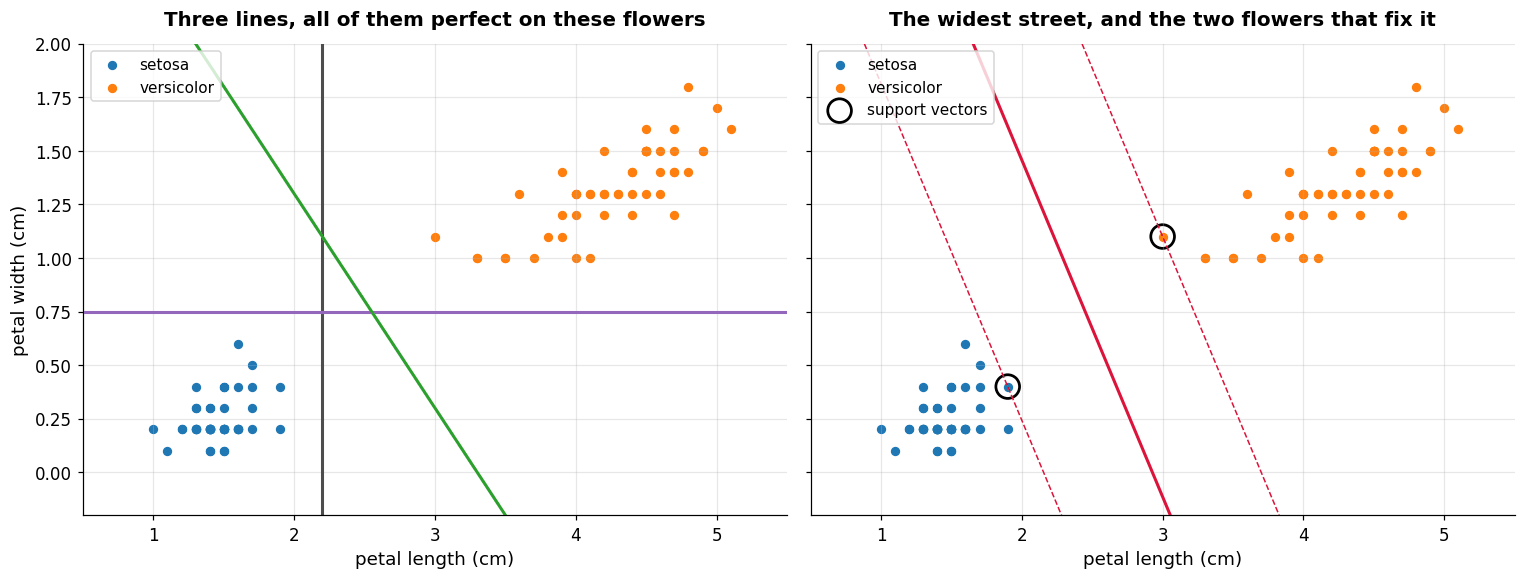

In [ ]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
try:                                        # the fallback pattern of 01C 3.2
    iris = pd.read_csv(url)
except Exception:                           # no network: the copy bundled with scikit-learn
    from sklearn.datasets import load_iris
    bundled = load_iris(as_frame=True)
    iris = bundled.frame.rename(columns=lambda name: name.replace(" (cm)", "").replace(" ", "_"))
    iris["species"] = iris.pop("target").map(dict(enumerate(bundled.target_names)))

petals = ["petal_length", "petal_width"]
species_colours = {"setosa": "tab:blue", "versicolor": "tab:orange", "virginica": "tab:green"}


def draw_line(axis, w, b, level=0.0, **style):
    """Draw the line w[0]*length + w[1]*width + b = level across the current axes."""
    grid_l, grid_w = np.meshgrid(np.linspace(0, 8, 400), np.linspace(-0.5, 3.5, 400))
    axis.contour(grid_l, grid_w, w[0] * grid_l + w[1] * grid_w + b, levels=[level], **style)


easy = iris[iris["species"] != "virginica"]
X_easy, y_easy = easy[petals], easy["species"]

# Three lines drawn by hand, as (w, b): each one separates the two species perfectly.
by_hand = [((1.0, 0.0), -2.2), ((0.0, 1.0), -0.75), ((1.0, 1.0), -3.3)]
side = lambda w, b: np.sign(X_easy.to_numpy() @ np.array(w) + b)
for w, b in by_hand:
    assert (side(w, b)[y_easy == "setosa"] < 0).all() and (side(w, b)[y_easy == "versicolor"] > 0).all()

# The maximal-margin line. A huge C means "no flower may stand inside the street" (section 3.3).
widest = SVC(kernel="linear", C=1e6).fit(X_easy, y_easy)
w, b = widest.coef_[0], widest.intercept_[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.4), sharex=True, sharey=True)
for axis in axes:
    for name, group in easy.groupby("species"):
        axis.scatter(group["petal_length"], group["petal_width"], s=26,
                     color=species_colours[name], label=name)
    axis.set_xlim(0.5, 5.5)
    axis.set_ylim(-0.2, 2.0)
    axis.set_xlabel("petal length (cm)")
axes[0].set_ylabel("petal width (cm)")
for (w_hand, b_hand), colour in zip(by_hand, ["0.3", "tab:purple", "tab:green"]):
    draw_line(axes[0], w_hand, b_hand, colors=colour, linewidths=2)
axes[0].set_title("Three lines, all of them perfect on these flowers")
axes[0].legend(loc="upper left")

draw_line(axes[1], w, b, 0.0, colors="crimson", linewidths=2)
for level in (-1.0, 1.0):
    draw_line(axes[1], w, b, level, colors="crimson", linewidths=1, linestyles="dashed")
axes[1].scatter(X_easy.iloc[widest.support_, 0], X_easy.iloc[widest.support_, 1], s=240,
                facecolors="none", edgecolors="black", linewidths=1.8, label="support vectors")
axes[1].set_title("The widest street, and the two flowers that fix it")
axes[1].legend(loc="upper left")
plt.show()

On the left, three lines that all classify every flower correctly, and nothing in the training data
to choose between them. Each passes close to one class or the other, and a new flower near that
class would be misclassified. On the right, the maximal-margin line: the solid line is the boundary,
the dashed lines are the edges of the street, and two flowers sit exactly on the edges.

**The mathematics.** Write the boundary as $f(\mathbf{x}) = \mathbf{w}\cdot\mathbf{x} + b = 0$ and
code the two classes as $y = -1$ and $y = +1$. The distance of a point from the line is
$|f(\mathbf{x})|/\lVert\mathbf{w}\rVert$. The same line can be written with $\mathbf{w}$ and $b$ both
multiplied by any number, so fix the scale by asking that the flowers nearest to it have
$|f| = 1$: the edges of the street are the lines $f = \pm 1$, and its width is
$2/\lVert\mathbf{w}\rVert$. Making the street as wide as possible is then

$$
\text{minimise } \tfrac12 \lVert\mathbf{w}\rVert^2
\quad\text{subject to}\quad y_i\, f(\mathbf{x}_i) \;\ge\; 1 \ \text{ for every training sample } i .
$$

The constraint says every flower is on its own side of the street, at or beyond the edge. This is
what `SVC(kernel="linear")` solves when `C` is made huge — section 3.3 says what `C` is, and why the
constraint has to be relaxed for most data. The flowers on the edges are the **support vectors**,
and the claim of the method's name is that they alone hold the line up. The cell checks it by
refitting on the support vectors only.

In [ ]:
print(f"w = ({w[0]:.4f}, {w[1]:.4f}),  b = {b:.4f}   (positive side: {widest.classes_[1]})")
print(f"width of the street: 2/|w| = {2 / np.linalg.norm(w):.3f} cm")
print(f"\nsupport vectors: {len(widest.support_)} of {len(y_easy)} flowers")
print(easy.iloc[widest.support_][petals + ["species"]])

only_them = SVC(kernel="linear", C=1e6).fit(X_easy.iloc[widest.support_], y_easy.iloc[widest.support_])
print(f"\nrefitted on the support vectors alone: w = ({only_them.coef_[0][0]:.4f}, "
      f"{only_them.coef_[0][1]:.4f}),  b = {only_them.intercept_[0]:.4f}")

w = (1.2941, 0.8235),  b = -3.7882   (positive side: versicolor)
width of the street: 2/|w| = 1.304 cm

support vectors: 2 of 100 flowers


    petal_length  petal_width     species
44           1.9          0.4      setosa
98           3.0          1.1  versicolor

refitted on the support vectors alone: w = (1.2941, 0.8235),  b = -3.7882


Two flowers out of 100 — setosa 44, with petals 1.9 × 0.4 cm, and versicolor 98, with 3.0 × 1.1 cm —
and the line refitted on those two alone is the same line, to every printed digit. The other 98
flowers could be deleted, or moved anywhere on their own side of the street, and nothing would
change.

That is a real difference from logistic regression, where every sample pulls on the line a
little, however far away it is. Section 3.6 shows where the difference comes from. It is also a
fragility: move one of those two flowers and the line moves with it.

## 3.2 The same line, written with the support vectors

The solution has a second form, and `05B` is built on it. Solving the problem above gives the
weights as a combination of the training samples themselves,

$$
\mathbf{w} \;=\; \sum_i \alpha_i\, y_i\, \mathbf{x}_i ,
\qquad\text{so}\qquad
f(\mathbf{x}) \;=\; \sum_i \alpha_i\, y_i\, \langle \mathbf{x}_i, \mathbf{x}\rangle \;+\; b ,
$$

with $\alpha_i \ge 0$, and $\alpha_i = 0$ for every sample that is not a support vector. That is
the algebra behind what the refit just showed: the other flowers have $\alpha_i = 0$ and are not in
the sum at all.

Read the right-hand side: a new flower is classified by **its dot products with the support
vectors**, and nothing else. `scikit-learn` keeps those two numbers $\alpha_i y_i$ in `dual_coef_`
and the support vectors in `support_vectors_`, so the sum can be checked by hand.

In [ ]:
alpha_y = widest.dual_coef_[0]                 # the products alpha_i * y_i, one per support vector
from_support = X_easy.to_numpy() @ (alpha_y @ widest.support_vectors_) + widest.intercept_[0]
print(f"largest difference between the sum over support vectors and decision_function: "
      f"{np.abs(from_support - widest.decision_function(X_easy)).max():.1e}")
print(f"alpha_i * y_i for the two support vectors: {alpha_y.round(4)}")

largest difference between the sum over support vectors and decision_function: 3.6e-15
alpha_i * y_i for the two support vectors: [-1.1765  1.1765]


## 3.3 The soft margin, and the dial `C`

Perfectly separable data are rare. Versicolor and virginica overlap — `02B` §10.5's flower 70 sits
among the virginicas, and `04A` §8 found three flowers with identical petals that are not all the
same species. For data like these no street exists without flowers in it, and the problem of
section 3.1 has no solution at all.

**There is a second reason, and it is the more important one.** Even when a separating line does
exist, insisting on it is usually a bad idea. The objection is standard: a classifier built on a
separating
hyperplane must classify every training observation correctly, which makes it acutely sensitive to
individual observations — and a boundary that moves when one point moves is a boundary that has
probably overfitted. Section 3.2's two flowers are exactly that
worry made concrete: move one of them and the line moves with it. So the soft margin is not only a
repair for overlapping data — it is the **flexibility dial**, and `C` is where it lives.

The **soft margin** allows violations, and charges for them. Each sample gets a **slack**
$\xi_i \ge 0$: zero if it is on its own side beyond the edge of the street, between 0 and 1 if it
is inside the street but still on the right side, and more than 1 if it is on the wrong side
altogether. The problem becomes

$$
\text{minimise } \tfrac12 \lVert\mathbf{w}\rVert^2 \;+\; C \sum_i \xi_i
\quad\text{subject to}\quad y_i\, f(\mathbf{x}_i) \;\ge\; 1 - \xi_i ,\;\; \xi_i \ge 0 .
$$

`C` sets the price of a violation. **Large `C`**: violations are expensive, so the street narrows
until few samples are in it. **Small `C`**: violations are cheap, so the street widens and many
samples stand in it. Every sample on the edge of the street, inside it, or on the wrong side of it
altogether is a support vector — everything with $y_i f(\mathbf{x}_i) \le 1$.

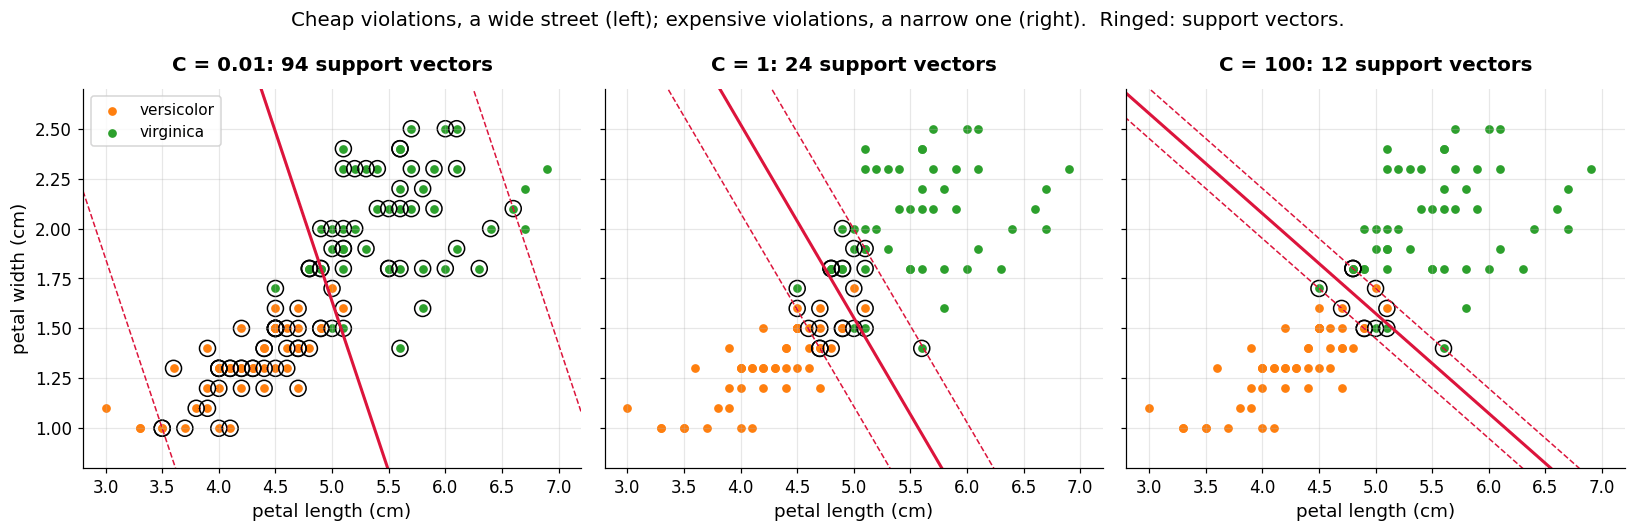

       C   support vectors   street width (cm)   cross-validated accuracy


    0.01                94               3.230                      0.950
     0.1                50               1.312                      0.940
       1                24               0.637                      0.950
      10                15               0.360                      0.940
     100                12               0.224                      0.930
    1000                12               0.224                      0.930


In [ ]:
hard_pair = iris[iris["species"] != "setosa"]
X_hard, y_hard = hard_pair[petals], hard_pair["species"]
flower_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.9), sharex=True, sharey=True)
for axis, C in zip(axes, [0.01, 1, 100]):
    machine = SVC(kernel="linear", C=C).fit(X_hard, y_hard)
    for name, group in hard_pair.groupby("species"):
        axis.scatter(group["petal_length"], group["petal_width"], s=22,
                     color=species_colours[name], label=name)
    draw_line(axis, machine.coef_[0], machine.intercept_[0], 0.0, colors="crimson", linewidths=2)
    for level in (-1.0, 1.0):
        draw_line(axis, machine.coef_[0], machine.intercept_[0], level, colors="crimson",
                  linewidths=1, linestyles="dashed")
    axis.scatter(X_hard.iloc[machine.support_, 0], X_hard.iloc[machine.support_, 1], s=110,
                 facecolors="none", edgecolors="black", linewidths=1)
    axis.set_title(f"C = {C}: {len(machine.support_)} support vectors")
    axis.set_xlim(2.8, 7.2)
    axis.set_ylim(0.8, 2.7)
    axis.set_xlabel("petal length (cm)")
axes[0].set_ylabel("petal width (cm)")
axes[0].legend(loc="upper left")
fig.suptitle("Cheap violations, a wide street (left); expensive violations, a narrow one (right)."
             "  Ringed: support vectors.", fontsize=13)
plt.show()

print(f"{'C':>8}{'support vectors':>18}{'street width (cm)':>20}{'cross-validated accuracy':>27}")
for C in [0.01, 0.1, 1, 10, 100, 1000]:
    machine = SVC(kernel="linear", C=C).fit(X_hard, y_hard)
    accuracy = cross_val_score(SVC(kernel="linear", C=C), X_hard, y_hard, cv=flower_folds).mean()
    print(f"{C:>8}{len(machine.support_):>18}{2 / np.linalg.norm(machine.coef_[0]):>20.3f}"
          f"{accuracy:>27.3f}")

**The geometry changes a great deal.** At `C = 0.01` the street is 3.23 cm wide — wider than the
region the flowers occupy — and 94 of the 100 flowers are support vectors: almost every flower
votes on the line. At `C = 100` the street is 0.22 cm wide and 12 flowers hold it. Beyond that
nothing changes: once `C` is large enough, the line is simply the one with the smallest total
violation, and the penalty no longer has a say in it.

**The accuracy hardly changes at all**: 0.93 to 0.95 across five orders of magnitude of `C`. With
two features, a straight line has little variance to control, and the flowers that decide the
accuracy are the overlapping ones that no line can place correctly.

`C` is the flexibility dial of the SVM, and it is the same dial as `03C`: a small `C` is a strong
penalty on $\lVert\mathbf{w}\rVert^2$ — a wide street is a small $\mathbf{w}$ — and so a stiffer
model. It is even the same name as `LogisticRegression`'s `C` (`03C` §6), and it points the same way:
**larger `C`, weaker penalty, more flexible model.**

**Which flowers end up as support vectors?** The ones the fit puts at or inside the edge of the
street — margin $y_i f(\mathbf{x}_i) \le 1$ — and only those. Everything comfortably outside
contributes nothing at all: delete it, or slide it further out, and the boundary does not move.
That sounds circular, because the boundary decides which flowers are inside and those flowers
decide the boundary, and it is: the fit is a fixed point, which is what the optimiser computes.
Section 3.6 gives the one-line reason — the hinge loss is *flat* out there, so a comfortable
flower produces no gradient and cannot pull. Optional section 3.4 shows the machinery.

> Two cautions on the letter `C`. Some textbooks use it for a **budget** of violations, which
> runs the other way: there, a larger `C` means a wider street. And with more than two classes,
> `SVC` fits one machine for every **pair** of classes and lets them vote (one-vs-one).

## 3.4 Optional: the algorithm, and which samples end up mattering

Section 3.3 stated which samples end up mattering. This section shows the machinery behind that
statement, and nothing later in the notebook depends on it.

It is worth saying that the standard texts skip it too: they note that the details
get technical, state the two facts they need — that the fit is a sum over training points, and that
the weights vanish off the support vectors — and go straight on to kernels. If the algebra below
does not land, you have lost nothing that section 3.6 or `05B` will ask for.

**The problem, in full.** With the labels coded $y_i = \pm 1$, the soft-margin machine solves

$$
\min_{\mathbf{w},\, b,\, \boldsymbol{\xi}} \;\; \tfrac12 \lVert\mathbf{w}\rVert^2 \;+\; C
\sum_{i=1}^{n} \xi_i
\qquad\text{subject to}\qquad
y_i\big(\mathbf{w}\cdot\mathbf{x}_i + b\big) \;\ge\; 1 - \xi_i ,
\qquad \xi_i \ge 0 .
$$

This is a **convex quadratic programme**: a quadratic objective with linear constraints. It has one
global minimum — no local minima, no restarts, no random initialisation — and refitting on the same
data returns the same line to the last digit.

**How it is solved.** Not in that form. Every library solves the equivalent **dual** problem, in
which the unknowns are one weight $\alpha_i$ per training sample:

$$
\max_{\boldsymbol{\alpha}} \;\; \sum_{i=1}^{n} \alpha_i \;-\; \tfrac12 \sum_{i=1}^{n}\sum_{j=1}^{n}
\alpha_i \alpha_j \, y_i y_j \, \langle \mathbf{x}_i, \mathbf{x}_j\rangle
\qquad\text{subject to}\qquad
0 \le \alpha_i \le C , \qquad \sum_{i=1}^{n} \alpha_i y_i = 0 .
$$

Three things about this form are worth noticing, and all three matter later.

- **The samples enter only through dot products** $\langle \mathbf{x}_i, \mathbf{x}_j\rangle$ —
  section 3.2's observation, now for the fit rather than the prediction. This is the opening `05B`
  needs.
- **The weights are capped at $C$.** In the separable problem of section 3.1 there is no cap; the
  soft margin adds one, and it is the whole of what `C` does.
- **The number of unknowns is the number of samples**, not the number of features. That is why a
  kernel SVM costs between $O(n^2)$ and $O(n^3)$ and why section 3.5 takes seconds on 14,000 events
  and would not scale to millions. `scikit-learn`'s `SVC` wraps **libsvm**, which solves this with
  **sequential minimal optimisation** (Platt, 1998): repeatedly pick two weights and optimise them
  exactly, which respects the constraint $\sum_i \alpha_i y_i = 0$ because two weights can move in
  opposite directions.

**What the solution looks like.** Optimality conditions for a constrained problem of this kind — the
Karush–Kuhn–Tucker conditions — force every training sample into exactly one of three states, each
one pairing a weight with a position relative to the street:

| | weight | margin $y_i f(\mathbf{x}_i)$ | what it is |
|---|---|---|---|
| **not a support vector** | $\alpha_i = 0$ | $> 1$ | beyond the street, on the correct side. No influence whatever |
| **free support vector** | $0 < \alpha_i < C$ | $= 1$ exactly | sitting on the edge of the street. These pin it |
| **bounded support vector** | $\alpha_i = C$ | $< 1$ | inside the street, or on the wrong side of it. Pulling at the cap |

So support vectors are **not chosen — they are what the solution turns out to contain**, namely
every sample with a non-zero weight. The cell below reads the three groups out of a fitted model:
`scikit-learn` stores the products $\alpha_i y_i$ for the support vectors in `dual_coef_`, so their
absolute values are the weights, and a weight equal to `C` marks a bounded one.

                            flowers            weight           margin y f(x)
not a support vector             76                 0        1.000 to 5.831
free support vector               2         0 < a < C        1.000 to 1.000
bounded support vector           22             a = C       -0.760 to 1.000

sum of alpha_i * y_i (the dual's constraint): 0.0e+00


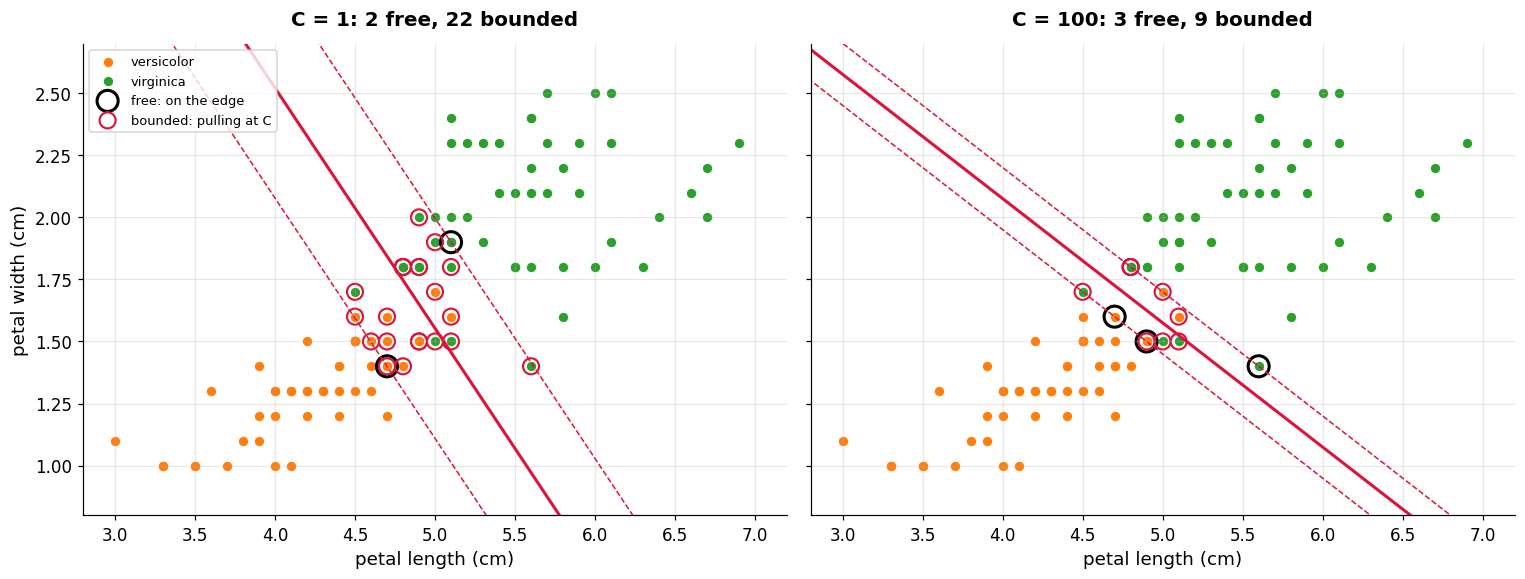

       C   support vectors    free   bounded
     0.1                50       3        47
       1                24       2        22
     100                12       3         9


In [ ]:
def three_groups(C_value):
    """Split the flowers into non-support vectors, free support vectors and bounded ones."""
    machine = SVC(kernel="linear", C=C_value).fit(X_hard, y_hard)
    label = np.where(y_hard == machine.classes_[1], 1, -1)          # the +-1 coding of the algebra
    margin = label * machine.decision_function(X_hard)
    weight = np.zeros(len(y_hard))
    weight[machine.support_] = np.abs(machine.dual_coef_[0])        # alpha_i, for support vectors
    free = (weight > 1e-9) & (weight < C_value - 1e-9)
    bounded = weight >= C_value - 1e-9
    return machine, margin, weight, free, bounded


machine, margin, weight, free, bounded = three_groups(1.0)
print(f"{'':26}{'flowers':>9}{'weight':>18}{'margin y f(x)':>24}")
for name, group, how in [("not a support vector", ~(free | bounded), "0"),
                         ("free support vector", free, "0 < a < C"),
                         ("bounded support vector", bounded, "a = C")]:
    print(f"{name:26}{group.sum():>9}{how:>18}"
          f"{margin[group].min():>13.3f} to {margin[group].max():.3f}")
print(f"\nsum of alpha_i * y_i (the dual's constraint): {machine.dual_coef_.sum():.1e}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.4), sharex=True, sharey=True)
for axis, C_value in zip(axes, [1.0, 100.0]):
    _, _, _, free_c, bounded_c = three_groups(C_value)
    drawn = SVC(kernel="linear", C=C_value).fit(X_hard, y_hard)
    for name, group in hard_pair.groupby("species"):
        axis.scatter(group["petal_length"], group["petal_width"], s=26,
                     color=species_colours[name], label=name)
    axis.scatter(X_hard.loc[free_c, "petal_length"], X_hard.loc[free_c, "petal_width"], s=190,
                 facecolors="none", edgecolors="black", linewidths=2, label="free: on the edge")
    axis.scatter(X_hard.loc[bounded_c, "petal_length"], X_hard.loc[bounded_c, "petal_width"], s=110,
                 facecolors="none", edgecolors="crimson", linewidths=1.4,
                 label="bounded: pulling at C")
    draw_line(axis, drawn.coef_[0], drawn.intercept_[0], 0.0, colors="crimson", linewidths=2)
    for level in (-1.0, 1.0):
        draw_line(axis, drawn.coef_[0], drawn.intercept_[0], level, colors="crimson",
                  linewidths=1, linestyles="dashed")
    axis.set_title(f"C = {C_value:g}: {int(free_c.sum())} free, {int(bounded_c.sum())} bounded")
    axis.set_xlim(2.8, 7.2)
    axis.set_ylim(0.8, 2.7)
    axis.set_xlabel("petal length (cm)")
axes[0].set_ylabel("petal width (cm)")
axes[0].legend(loc="upper left", fontsize=8.5)
plt.show()

print(f"{'C':>8}{'support vectors':>18}{'free':>8}{'bounded':>10}")
for C_value in [0.1, 1.0, 100.0]:
    _, _, _, free_c, bounded_c = three_groups(C_value)
    print(f"{C_value:>8g}{int(free_c.sum() + bounded_c.sum()):>18}"
          f"{int(free_c.sum()):>8}{int(bounded_c.sum()):>10}")

Read the table first. Every flower that is **not** a support vector has a margin above 1 — the
smallest is 1.000 — and every flower inside or beyond the street is one. The two free support
vectors sit at a margin of exactly 1.000, which is what "on the edge" means numerically, and the
twenty-two bounded ones run from −0.76 to 1.00: some merely inside the street, some on the wrong
side of the boundary altogether. The dual's constraint $\sum_i \alpha_i y_i = 0$ is satisfied to
machine precision.

**Why this is not circular.** The boundary decides which flowers have margin below 1, and those
flowers decide the boundary. That sounds like a loop, and it is — a **fixed point**, which is
exactly what the optimisation computes. Section 3.6's picture of the hinge loss is the same
statement in one line: the loss is flat beyond a margin of 1, so a flower out there produces no
gradient and cannot move anything; flowers at or inside the edge sit on the sloped part and pull.

**What overlap changes.** In the separable case of section 3.1 no flower is ever inside the street,
so no weight reaches the cap, every support vector is free, and two flowers were enough. With
overlap, most of the samples near the boundary end up **bounded**: pulling with weight exactly `C`
and not one bit more, however badly misplaced they are. That cap is the mechanical meaning of the
dial. It is also why a single absurd observation cannot drag an SVM the way it dragged the least
squares fit of `02A` §9 — its influence saturates.

The figure shows the two ends of the dial. At `C = 1` the street is wide enough to hold twenty-four
flowers, two of them on its edges. At `C = 100` violations are expensive, the street narrows to
twelve, and the boundary is now held up by a handful of flowers in the overlap. The counts beneath
make the pattern explicit: the number of **free** support vectors stays tiny at every setting — they
only have to pin a line — while the **bounded** ones are however many the street happens to contain.

## 3.5 The same dial on 14,000 events

The telescope data are the harder test: ten features, all standardised, and 14,265 training events.

In [ ]:
print(f"{'C':>6}{'cross-validated ROC AUC':>26}{'support vectors':>18}{'seconds':>10}")
for C in [0.01, 0.1, 1, 10]:
    start = time.time()
    machine = make_pipeline(StandardScaler(), SVC(kernel="linear", C=C))
    scores = cross_val_score(machine, X_train, y_train, cv=folds, scoring="roc_auc", n_jobs=-1)
    machine.fit(X_train, y_train)
    print(f"{C:>6}{scores.mean():>20.4f} +/- {scores.std():.4f}"
          f"{machine[-1].n_support_.sum():>12}{time.time() - start:>10.0f}")

     C   cross-validated ROC AUC   support vectors   seconds


  0.01              0.8327 +/- 0.0054        7050         4


   0.1              0.8328 +/- 0.0056        6912         4


     1              0.8328 +/- 0.0056        6896         5


    10              0.8328 +/- 0.0056        6893        10


Two surprises.

**The dial does nothing.** Across a factor of a thousand in `C`, the ROC AUC moves by one in the
fourth decimal. This is `03C` §5's finding with 442 patients again: a penalty removes variance, and
the variance of a linear fit scales with the number of parameters over the number of samples, so
ten
features and 14,000 events leave almost none to remove. What limits
this model is **bias** — a straight boundary through data that, as section 2.1's figure showed, are
not separated by a straight line. No setting of `C` bends it. `05B` does.

**About half the training events are support vectors** — around 6,900 of 14,265. On data that
overlap this much, a large share of the events stand inside the street, and every one of them helps
hold the line. The picture of section 3.1, where two flowers decided everything, is what happens when
the classes are well separated. It is not a general property of the method.

> `SVC` solves the problem exactly, at a cost that grows faster than the number of samples. For a
> *linear* SVM on data much larger than this, `LinearSVC` or `SGDClassifier(loss="hinge")` is far
> faster — at the price of an approximation, and of defaults that differ (`LinearSVC` minimises the
> **squared** hinge loss unless told otherwise).

## 3.6 The hinge loss: an SVM is a loss plus a penalty

The slack formulation hides how close the SVM is to something already in this course. At the best
solution, each slack is as small as its constraint allows: $\xi_i = 0$ if
$y_i f(\mathbf{x}_i) \ge 1$, and $\xi_i = 1 - y_i f(\mathbf{x}_i)$ otherwise. That is one function,

$$
\xi_i \;=\; \max\!\big(0,\; 1 - y_i f(\mathbf{x}_i)\big),
$$

the **hinge loss**. Substituting it, and dividing the whole objective by $C$, the SVM is

$$
\text{minimise } \sum_i \max\!\big(0,\; 1 - y_i f(\mathbf{x}_i)\big) \;+\; \lambda\,
\lVert\mathbf{w}\rVert^2,
\qquad \lambda = \frac{1}{2C} ,
$$

**a loss on the training data plus an L2 penalty** — the shape of every model since `03C`, with
 $\lambda = 1/(2C)$.

Logistic regression fits the same shape. Its loss is `02B` §5's cross-entropy; with the labels coded
as $\pm 1$ instead of $0/1$ and $\hat p = \sigma(f)$, that loss can be rewritten as
$\log\!\big(1 + e^{-y_i f(\mathbf{x}_i)}\big)$. The cell checks the rewriting numerically, then draws
both losses as functions of the **margin** $m = y f(\mathbf{x})$ — positive when a sample is on the
correct side, and the larger the further inside it is.

largest difference between 02B's cross-entropy and log(1 + exp(-y f)): 1.3e-13


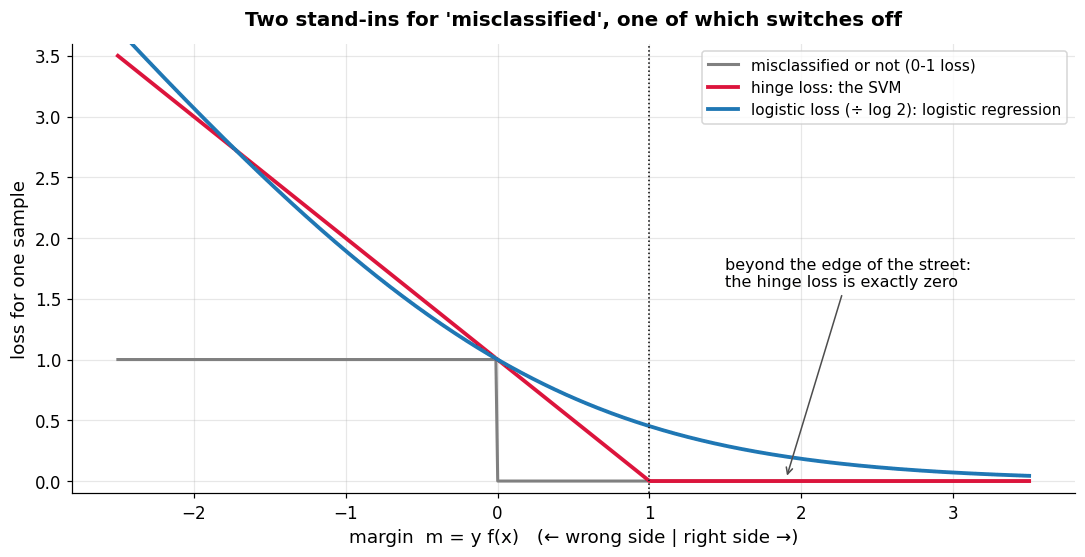

In [ ]:
sigmoid = lambda z: 1 / (1 + np.exp(-z))
scores_f = rng.normal(0, 3, 1000)                 # some values of f(x)
labels01 = rng.integers(0, 2, 1000)               # labels coded 0/1, as in 02B
labels_pm = 2 * labels01 - 1                      # the same labels coded -1/+1
cross_entropy = -(labels01 * np.log(sigmoid(scores_f)) + (1 - labels01) * np.log(1 - sigmoid(scores_f)))
rewritten = np.log(1 + np.exp(-labels_pm * scores_f))
print(f"largest difference between 02B's cross-entropy and log(1 + exp(-y f)): "
      f"{np.abs(cross_entropy - rewritten).max():.1e}")

margin = np.linspace(-2.5, 3.5, 500)
fig, axis = plt.subplots(figsize=(10, 5.2))
axis.plot(margin, (margin <= 0).astype(float), color="0.5", linewidth=2,
          label="misclassified or not (0-1 loss)")
axis.plot(margin, np.maximum(0, 1 - margin), color="crimson", linewidth=2.5,
          label="hinge loss: the SVM")
axis.plot(margin, np.log(1 + np.exp(-margin)) / np.log(2), color="tab:blue", linewidth=2.5,
          label="logistic loss (÷ log 2): logistic regression")
axis.axvline(1, color="black", linestyle=":", linewidth=1)
axis.annotate("beyond the edge of the street:\nthe hinge loss is exactly zero", xy=(1.9, 0.02),
              xytext=(1.5, 1.6), arrowprops={"arrowstyle": "->", "color": "0.3"}, fontsize=10.5)
axis.set_xlabel("margin  m = y f(x)   (← wrong side | right side →)")
axis.set_ylabel("loss for one sample")
axis.set_ylim(-0.1, 3.6)
axis.set_title("Two stand-ins for 'misclassified', one of which switches off")
axis.legend(loc="upper right")
plt.show()

The two losses are close relatives. Both are large for a sample on the wrong side, both grow
roughly linearly as it moves further in, and both fall as it moves to the correct side. The
difference is at the right-hand end. **The logistic loss never reaches zero**: a sample far on the
correct side still contributes a little, so every sample pulls on the line. **The hinge loss is
exactly zero beyond $m = 1$**, the edge of the street: those samples contribute nothing and can be
deleted without changing the fit. The support vectors are the rest — everything with $m \le 1$,
whether the hinge loss is positive there or, for a sample exactly on the edge, sitting at its
kink.

So a linear SVM should behave much like a logistic regression with the same penalty. On the
telescope data:

In [ ]:
svm = make_pipeline(StandardScaler(), SVC(kernel="linear", C=1)).fit(X_train, y_train)
logistic = make_pipeline(StandardScaler(), LogisticRegression(C=1)).fit(X_train, y_train)

svm_score = svm.decision_function(X_test)
print(f"test ROC AUC   linear SVM {roc_auc_score(y_test, svm_score):.4f}"
      f"   logistic regression {roc_auc_score(y_test, logistic.decision_function(X_test)):.4f}")
print(f"test events given the same class by both: "
      f"{(svm.predict(X_test) == logistic.predict(X_test)).mean():.1%}")

test ROC AUC   linear SVM 0.8406   logistic regression 0.8465


test events given the same class by both: 97.7%


The two agree on 97.7% of the test events, and their ROC AUCs differ by 0.006. Different losses,
the same penalty, nearly the same line. The practical differences between them are elsewhere: the
SVM's solution depends only on its support vectors, and — the next section — logistic regression
produces probabilities while the SVM does not.

> **Which to reach for.** When the classes are well separated, an SVM tends to behave better than
> logistic regression; in more overlapping regimes, logistic regression is often preferred. The
> reason for the first half is worth knowing, because it is a failure of logistic regression rather
> than a triumph of the SVM: on separable data the unpenalised logistic fit has no finite answer at
> all. Its coefficients **diverge** — though their *direction* converges to the optimal separating
> hyperplane — and the hinge's flat region is what stops the same thing happening to the SVM. These
> telescope events are firmly in the second half of the rule, which is why the two models agree
> here to a fraction of a percent.

### Optional: what separates the two, once the penalty is the same

The penalty is genuinely shared: `LogisticRegression` carries the same L2 term by default (`03C`
§6), and `SGDClassifier` will fit either loss with either penalty. So the loss is the *only*
primitive difference between them — but a surprising amount follows from it, and none of it can be
recovered by changing the penalty.

| | logistic regression | linear SVM |
|---|---|---|
| **loss** | $\log(1 + e^{-y f})$ — positive everywhere | $\max(0,\, 1 - y f)$ — exactly zero beyond the margin |
| **which samples affect the fit** | every one, by a little | only those with $y f \le 1$ (section 3.4) |
| **what the fit produces** | a probability, by maximum likelihood (`02B` §5.2) | a distance, needing calibration (section 3.7) |
| **the best possible $f$** | the log-odds themselves | only the sign of $p - \tfrac12$ |
| **more than two classes** | one model, softmax (`02B` §10) | one machine per pair, then a vote |
| **with a kernel** (`05B`) | every sample keeps a coefficient | only the support vectors do |
| **how it is solved** | smooth: Newton or quasi-Newton | a quadratic programme, by SMO |

The row that matters most in practice is the second-to-last. `05B` will replace dot products by
kernels, and the cost of a prediction is then the number of samples that carry a non-zero
coefficient. For an SVM that is the support vectors; for kernel logistic regression it is *all of
them*, which is why the kernel version is rarely used — and why the method built to repair it, the
import vector machine, works by selecting a small subset of samples to keep.

**So is an SVM just logistic regression with the loss swapped?** In the binary, linear case, with
the same penalty: yes, exactly. Minimising $\sum_i \max(0,\, 1 - y_i f(\mathbf{x}_i)) +
\lVert\mathbf{w}\rVert^2/(2C)$ *is* the soft-margin problem of section 3.3 — the same objective
written in two ways — so a generic optimiser handed that expression must land where `SVC` lands.
The cell checks it.

In [ ]:
from scipy.optimize import minimize

label = np.where(y_hard == "virginica", 1, -1)          # the +-1 coding again
features = X_hard.to_numpy()


def loss_plus_penalty(parameters, C_value):
    """Hinge loss summed over the flowers, plus the L2 penalty, with lambda = 1/(2C)."""
    w, b = parameters[:2], parameters[2]
    margins = label * (features @ w + b)
    return np.maximum(0, 1 - margins).sum() + (w @ w) / (2 * C_value)


for C_value in [0.1, 1, 10]:
    found = minimize(loss_plus_penalty, np.zeros(3), args=(C_value,), method="Nelder-Mead",
                     options={"xatol": 1e-10, "fatol": 1e-12, "maxiter": 200_000, "maxfev": 200_000})
    machine = SVC(kernel="linear", C=C_value).fit(X_hard, y_hard)
    sign = 1 if machine.classes_[1] == "virginica" else -1
    print(f"C = {C_value}")
    print(f"   minimising the loss by hand : w = {found.x[:2].round(3)}, b = {found.x[2]:8.3f}")
    print(f"   SVC(kernel='linear')        : w = {(sign * machine.coef_[0]).round(3)},"
          f" b = {sign * machine.intercept_[0]:8.3f}")

C = 0.1
   minimising the loss by hand : w = [1.19  0.952], b =   -7.429
   SVC(kernel='linear')        : w = [1.19  0.952], b =   -7.427
C = 1
   minimising the loss by hand : w = [2.183 2.254], b =  -14.415
   SVC(kernel='linear')        : w = [2.183 2.254], b =  -14.415
C = 10
   minimising the loss by hand : w = [2.759 4.828], b =  -21.207
   SVC(kernel='linear')        : w = [2.759 4.829], b =  -21.209


They agree to the optimiser's tolerance, at every setting of `C`. Nothing about support vectors,
margins or quadratic programmes was supplied to the minimiser — only the loss and the penalty — and
the maximal-margin line came back out.

Three conditions are doing work in that "exactly", and each of them is a genuine limit.

- **The penalty must be there.** With the hinge loss alone and separable data, any line that clears
  every flower by a margin of 1 scores zero, and there are infinitely many. The penalty is what
  picks the widest street out of that set.
- **Binary only.** Logistic regression generalises to many classes through the softmax of `02B`
  §10.2, which is one model; the hinge loss does not, and `SVC` instead fits one machine per pair
  (section 3.3).
- **The equivalence is with the *penalised* logistic regression.** Comparing against an unpenalised
  fit compares two things at once.

`scikit-learn` makes the point in its own way: `SGDClassifier` takes the loss as an argument, and
the documentation states plainly that `loss="hinge"` gives a linear SVM while `loss="log_loss"`
gives logistic regression. One estimator, one keyword, two methods — which is the whole content of
this section.

### Then why is this a separate method at all?

The fair question, once the equivalence is on the table: if an SVM is the penalised model of `03C`
with one loss swapped for another, why does it get its own name, its own vocabulary and its own
hour?

**Because the equivalence is a unification, not a reduction.** The
standard treatments present it exactly this way, as *the SVM viewed as a penalisation method* — the
point being to recognise a familiar shape in something built from a different starting point.
Neither method is a special case of the other. They are two members of
one family, and the family — loss plus penalty — is what the course has been teaching since `03C`.
Read in the other direction, logistic regression is the SVM with the log loss.

**Because the loss changes what is being estimated, not just how it is fitted.** The table of
 population minimisers is the sharpest statement of it:
the hinge loss is minimised by $\mathrm{sign}[\,p(x) - \tfrac12\,]$, the classifier itself, while
every other loss in common use — the log loss included — is minimised by some transformation of the
class probabilities. The hinge alone estimates the decision. That is why section 3.7's scores are not
probabilities: it is not an oversight of the implementation but the object the loss was built to
recover.

**Because of what the construction hands you, which the loss alone does not.** Section 3.2 wrote
the fit as a sum over training points, $f(x) = \sum_i \alpha_i \langle x, x_i\rangle$, and that form
is the doorway to `05B`: replace the inner product with a kernel and the whole method becomes
non-linear. Be careful about what is the SVM's own, though. The *form* is general — the same sum
$f(x) = \sum_i \alpha_i K(x, x_i)$ solves the penalised problem for any loss, which is why `05B`
can kernelise ridge regression without an SVM anywhere in sight.
What belongs to the hinge is that **an $\alpha_i$ can come out exactly zero** — the flat part of
figure 3.6 again, where a comfortable point contributes nothing and so drops out of the sum.
Kernel ridge regression and Gaussian processes have no flat part and keep every training point.

How much that buys depends entirely on the overlap, and the notebook has both extremes printed.
On the separable pair of section 3.2 it is 2 support vectors out of 100. On these telescope
events at $C = 1$ it is 6,896 out of 14,265 — barely half, because section 3.4's third group,
the points inside the margin, are all support vectors, and with classes this tangled most points
are inside it. Sparsity is real and it is the hinge's own, but it is a property of the *problem*
as much as of the method.

**And because maximising the margin turns out not to be the distinguishing feature**, which is
worth knowing precisely because it sounds as though it should be. Every loss in that table except
squared error is *margin maximising*: on separable data, as the
penalty is weakened, the solution approaches the optimal separating hyperplane. The
measurement above the table showed logistic regression doing it. What the hinge gives is that
solution **at any penalty strength, from a handful of samples** — which is a computational and
representational advantage, not a different destination.

In [ ]:
max_margin = widest.coef_[0] / np.linalg.norm(widest.coef_[0])     # the hard-margin direction

print(f"{'logistic penalty':>18}{'angle to the maximum-margin direction':>42}")
for strength in [1, 100, 1e4, 1e6, 1e8]:
    # newton-cg, and a tight tolerance: at a weak penalty the loss surface is nearly flat, and the
    # default solver stops long before the optimum (it reports 26 degrees at C = 1e4).
    fitted = LogisticRegression(C=strength, solver="newton-cg", tol=1e-14, max_iter=10**6
                                ).fit(X_easy, y_easy)
    direction = fitted.coef_[0] / np.linalg.norm(fitted.coef_[0])
    angle = np.degrees(np.arccos(np.clip(abs(direction @ max_margin), -1, 1)))
    print(f"{strength:>18g}{angle:>38.2f}°")

  logistic penalty     angle to the maximum-margin direction
                 1                                  9.98°
               100                                  6.08°
             10000                                  3.08°
             1e+06                                  1.35°
             1e+08                                  0.53°


Weakening the penalty walks logistic regression to within half a degree of the maximum-margin line.
So the honest summary is not "one maximises the margin and the other does not". It is that the hinge
loss reaches that solution **at any penalty strength and with only a handful of samples**, while
logistic regression reaches it only in the limit of no penalty at all, using every sample on the way.

Which to prefer follows from the table rather than from the geometry: **logistic regression when the
output must be a probability or there are several classes; the SVM when the kernel of `05B` is
coming and the sparsity pays.**

## 3.7 SVM scores are distances, not probabilities

`03A` §8 listed support vector machines first among the models whose scores are not honest
probabilities, and promised the reason: *their scores are distances*. Here it is.

`decision_function` returns $f(\mathbf{x}) = \mathbf{w}\cdot\mathbf{x} + b$. Divided by
$\lVert\mathbf{w}\rVert$ it is the signed distance from the boundary, in standardised feature units;
undivided, it is the distance measured in half-widths of the street — $f = 1$ is on its edge. Beyond
that edge the hinge loss stops caring how far a sample is; and more fundamentally, the best possible
$f$ under the hinge loss only has to get the **sign** of $p(\text{gamma}) - \tfrac12$ right, where
the logistic loss is best when $f$ is the log-odds themselves. Nothing in the fit ties a value of
$f$ to how often such events are gamma.

scores on the test events run from -6.26 to 2.24; |w| = 1.354
share of scores that happen to fall between 0 and 1: 24.6%


ROC AUC of the calibrated probabilities: 0.8406   (the ranking is unchanged)


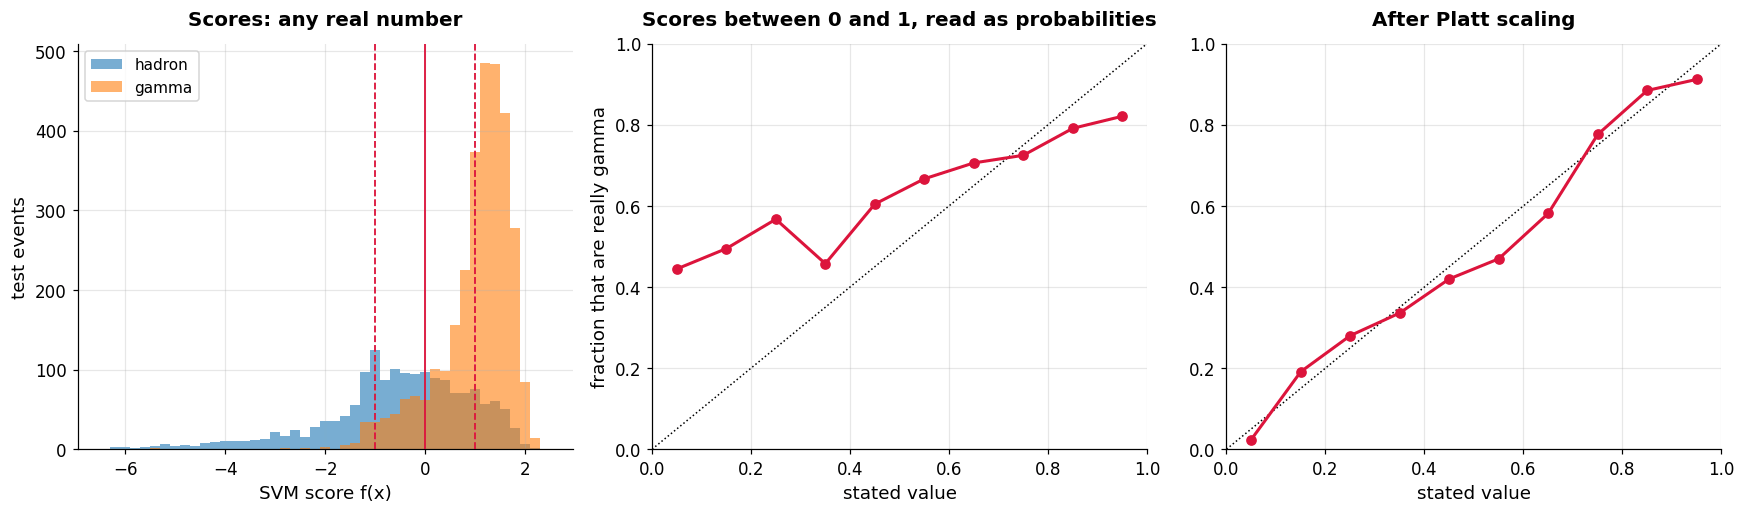

In [ ]:
norm_w = np.linalg.norm(svm[-1].coef_[0])
print(f"scores on the test events run from {svm_score.min():.2f} to {svm_score.max():.2f};"
      f" |w| = {norm_w:.3f}")
print(f"share of scores that happen to fall between 0 and 1: {((svm_score >= 0) & (svm_score <= 1)).mean():.1%}")

# Platt scaling: fit a sigmoid from score to probability, on held-out folds of the training set.
# ensemble=False: fit the sigmoid on cross-validated scores, then apply it to the one SVM
# trained on everything.  The default, ensemble=True, averages five SVMs instead.
platt = CalibratedClassifierCV(make_pipeline(StandardScaler(), SVC(kernel="linear", C=1)),
                               method="sigmoid", cv=5, ensemble=False).fit(X_train, y_train)
probability = platt.predict_proba(X_test)[:, 1]
print(f"ROC AUC of the calibrated probabilities: {roc_auc_score(y_test, probability):.4f}"
      f"   (the ranking is unchanged)")

truth = np.asarray(y_test)
edges = np.linspace(0, 1, 11)
centres = (edges[:-1] + edges[1:]) / 2


def observed(values):
    """Fraction of gamma events among the test events whose value falls in each bin."""
    which = np.digitize(values, edges[1:-1])
    inside = (values >= 0) & (values <= 1)
    return np.array([truth[inside & (which == i)].mean() if (inside & (which == i)).sum() >= 20
                     else np.nan for i in range(len(centres))])


fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
bins = np.linspace(-6.5, 2.5, 46)
axes[0].hist(svm_score[truth == 0], bins=bins, color=hadron_colour, alpha=0.6, label="hadron")
axes[0].hist(svm_score[truth == 1], bins=bins, color=gamma_colour, alpha=0.6, label="gamma")
for level, style in [(0, "-"), (-1, "--"), (1, "--")]:
    axes[0].axvline(level, color="crimson", linestyle=style, linewidth=1.2)
axes[0].set_xlabel("SVM score f(x)")
axes[0].set_ylabel("test events")
axes[0].set_title("Scores: any real number")
axes[0].legend(loc="upper left")

for axis, values, title in [(axes[1], svm_score, "Scores between 0 and 1, read as probabilities"),
                            (axes[2], probability, "After Platt scaling")]:
    axis.plot([0, 1], [0, 1], color="black", linewidth=1, linestyle=":")
    axis.plot(centres, observed(values), "o-", color="crimson", linewidth=2)
    axis.set_xlim(0, 1)
    axis.set_ylim(0, 1)
    axis.set_xlabel("stated value")
    axis.set_title(title)
axes[1].set_ylabel("fraction that are really gamma")
plt.show()

**Left.** The scores run from −6.26 to 2.24, and the dashed lines at ±1 are the edges of the
street. Nothing confines them to $[0, 1]$.

**Middle.** A quarter of the test scores do happen to lie between 0 and 1, and it is tempting to
read those as probabilities. This is the reliability diagram of `03A` §8, and it shows why not:
events scoring about 0.25 are gamma more than half the time, not a quarter of it, and at the low
end the points sit far above the dotted diagonal that honest probabilities would follow.

**Right.** The standard repair is **Platt scaling**: fit a sigmoid that maps the score
to a probability, $\hat p = 1/(1 + e^{A f + B})$, on data the SVM was not trained on.
`CalibratedClassifierCV` fits it on cross-validated scores from inside the training set, and the
result follows the diagonal. It is a monotone relabelling of one model's scores, so the ranking —
and the ROC AUC, 0.8406 — is untouched. `SVC(probability=True)` runs the same procedure internally,
and its probabilities can then disagree with `predict` for samples close to the boundary, because
the two are computed differently.

> Two settings worth knowing. `ensemble=True`, which `CalibratedClassifierCV` uses by default,
> averages the calibrated outputs of five SVMs fitted on four fifths of the data each; that is no
> longer one model's scores relabelled, and the ranking can move. And `method="isotonic"` fits a
> free monotone curve instead of a sigmoid, which is worth trying when there are many samples to
> calibrate on (Niculescu-Mizil & Caruana, 2005).

> **An SVM ranks samples; it does not estimate probabilities.** Use its scores for ROC AUC and for
> thresholds chosen on validation data. If the numbers themselves will be used — multiplied by a
> cost, averaged into a rate — calibrate them first, on data the model has not seen.

# 4. The two methods against the rest

## 4.1 Nearest neighbours, the SVM and the trees, on the same events

Class 4 left a standard to meet. The cell below scores every method of this notebook against the
logistic regression of `02B` and the two tree ensembles of Class 4, on the same folds.

In [ ]:
contenders = [
    ("logistic regression (02B)", make_pipeline(StandardScaler(), LogisticRegression())),
    ("linear SVM, C = 1", make_pipeline(StandardScaler(), SVC(kernel="linear", C=1))),
    ("31 nearest neighbours", make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=31))),
    ("random forest, 300 trees (04B)", RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                                              random_state=0)),
    ("gradient boosting (04C)", HistGradientBoostingClassifier(random_state=0)),
]
print(f"{'':32}{'cross-validated ROC AUC':>26}{'seconds':>10}")
for name, model in contenders:
    start = time.time()
    scores = cross_val_score(model, X_train, y_train, cv=folds, scoring="roc_auc", n_jobs=-1)
    print(f"{name:32}{scores.mean():>18.3f} +/- {scores.std():.3f}{time.time() - start:>10.0f}")

                                   cross-validated ROC AUC   seconds
logistic regression (02B)                    0.837 +/- 0.007         0


linear SVM, C = 1                            0.833 +/- 0.006         3


31 nearest neighbours                        0.900 +/- 0.004         0


random forest, 300 trees (04B)               0.935 +/- 0.002         7


gradient boosting (04C)                      0.934 +/- 0.004         0


Three tiers, each far outside the fold spreads.

**The two straight boundaries tie at the bottom**, at 0.83 and 0.84 — section 3.6's result, now on
 the same
folds as everything else.

**Nearest neighbours is well ahead of them, at 0.90.** With no fitting at all, only a sensible
scaling and a sensible $k$, it captures the curved boundary of section 2.1's figure that no straight
line can.

**The tree ensembles are ahead again, at about 0.93.** On a table of measured features this is
Class 4's result once more, and the practical rule of `04C` §9 stands: fit a boosted model first.

What the SVM needs is a curved boundary. `05B` gives it one, and section 3.2 is where it starts:
the score of a new sample is a sum of **dot products with the support vectors**. The **kernel
trick** replaces each of those dot products by a similarity between the two samples — for the
commonest kernel, one built from the distance of section 1.

## 4.2 What useless features do to each

The comparison above gave every method the same ten features, all of them built by physicists to
separate the two kinds of shower. Real tables are rarely that clean: they carry columns that were
easy to record, or that mattered for something else, or that carry nothing at all.

This is where the arithmetic of section 1 bites. **Every feature enters the distance, informative
or not.** A tree simply never splits on a useless column; a distance cannot ignore one. The cell
adds columns of pure noise to the telescope data and scores both kinds of method on the result.

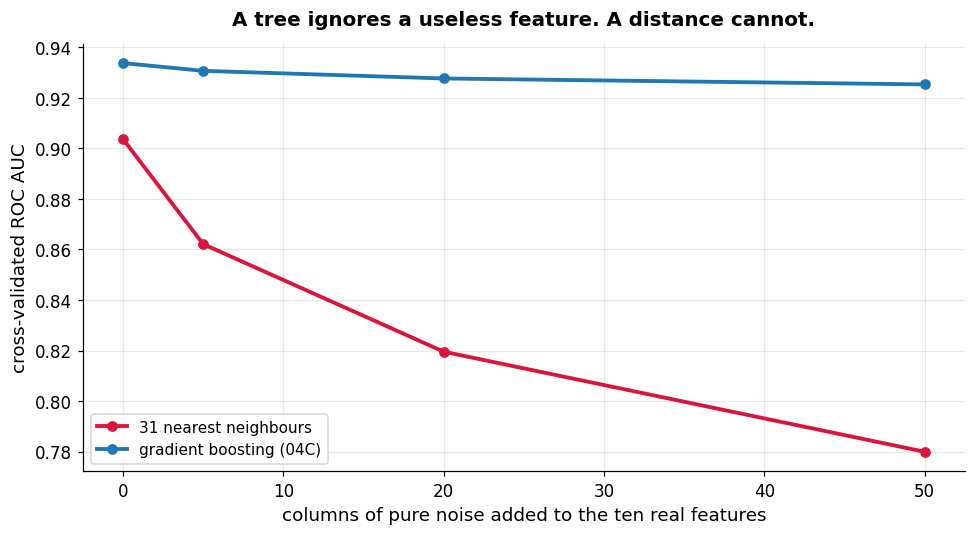

  noise columns   nearest neighbours   gradient boosting
              0                0.904               0.934
              5                0.862               0.931
             20                0.820               0.928
             50                0.780               0.925


In [ ]:
noise_rng = np.random.default_rng(0)
noise_counts = [0, 5, 20, 50]
knn_curve, boosting_curve = [], []

for how_many in noise_counts:
    padded = X_train.copy()
    for j in range(how_many):
        padded[f"noise{j}"] = noise_rng.normal(size=len(padded))
    knn_curve.append(cross_val_score(
        make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=31, weights="distance")),
        padded, y_train, cv=folds, scoring="roc_auc", n_jobs=-1).mean())
    boosting_curve.append(cross_val_score(
        HistGradientBoostingClassifier(random_state=0),
        padded, y_train, cv=folds, scoring="roc_auc", n_jobs=-1).mean())

fig, axis = plt.subplots(figsize=(9, 5))
axis.plot(noise_counts, knn_curve, "o-", color="crimson", linewidth=2.5,
          label="31 nearest neighbours")
axis.plot(noise_counts, boosting_curve, "o-", color="tab:blue", linewidth=2.5,
          label="gradient boosting (04C)")
axis.set_xlabel("columns of pure noise added to the ten real features")
axis.set_ylabel("cross-validated ROC AUC")
axis.set_title("A tree ignores a useless feature. A distance cannot.")
axis.legend()
plt.show()

print(f"{'noise columns':>15}{'nearest neighbours':>21}{'gradient boosting':>20}")
for how_many, near, boosted in zip(noise_counts, knn_curve, boosting_curve):
    print(f"{how_many:>15}{near:>21.3f}{boosted:>20.3f}")

Fifty columns of noise — five times as many useless features as useful ones, which is modest by the
standards of a real measurement log — cost nearest neighbours about 0.12 of ROC AUC and the boosted
trees about 0.01. The reason is section 1's formula and nothing else: each noise column adds its own
squared difference to every distance, so the genuine signal becomes a smaller and smaller share of
what decides who is a neighbour. It is the same arithmetic that made `fSize` invisible in raw units,
with the roles reversed.

**This is the fundamental limitation of every method in this notebook**, and no amount of tuning
answers it: `k`, `C` and the metric all take the features as given. The remedies are to select or
build better features, which is where `06A`'s PCA and Class 9's learned representations come in, or
to use a method that selects as it fits — `03C` §4's lasso, or a tree.

> Selecting features properly is harder than it looks, and the course does not lecture on it. The
> extra notebook `X1` does: how the best of many useless features comes to look good, why the
> selection has to happen inside the resampling loop, and what to do when features arrive in
> correlated groups.

# 5. When these are the wrong tools

*This is the notebook's* **when this is the wrong tool** *section, as in `04A` §11, `04B` §9.1 and
`04C` §10.*

**The features have no common scale.** Every method here depends on distances or on
$\lVert\mathbf{w}\rVert$, so everything depends on how the features were scaled (section 1). It is
the first practical step of the method, and for the plain reason that features are measured in
different units.
Standardising is a default, not a guarantee: a heavy-tailed feature, or a categorical one coded as
numbers, can still dominate or distort the distance. Trees do not have this problem at all.

**There are many features, and most carry nothing.** Section 4.2 measured it: fifty noise columns
cost nearest neighbours 0.12 of ROC AUC and the boosted trees 0.01. A tree ignores a feature it
never splits on; a distance cannot. The same thing in geometry: where the class probabilities
change in only one direction, a spherical neighbourhood reaches into the neighbouring class along
all the others, which is what the adaptive metrics of section 2.3 repair. How badly this goes as
the count grows is `06A`'s subject — the **curse of dimensionality**.

**Predictions must be fast, or the training set is huge.** kNN does all its work at prediction
time, and the whole training set must be kept and consulted. `scikit-learn` softens this by storing
the samples in a search tree — a KD-tree here — so that a query need not be compared with all of
them; that helps in a few dimensions and stops helping in many, which is `06A`'s subject again. The
standard remedies are **editing** and **condensing** the stored set — dropping samples that never
change an answer — and there are documented cases where nearest neighbours were simply too slow to
use online and a network was trained to imitate them. A telescope classifying events in real time
still wants a model that is fixed once trained.

**You need probabilities.** An SVM's scores need calibrating first (section 3.7). kNN's vote shares
are probabilities of a crude kind — with $k = 31$ and one vote each, they come in steps of
$1/31$.

**You need predictions outside the training data.** kNN can only return the classes or averages of
samples it has stored. Like a tree, it cannot extrapolate.

**The boundary is curved and you are using a straight one.** Sections 3.5 and 4.1: `C` cannot fix
bias. That is the case for `05B`.

## 5.1 So where are they the right tool?

Section 4.1 put both methods below the tree ensembles on a table of measured features, and section
4.2 showed how badly they take useless columns. It would be fair to ask what they are still for.
The answer is that their modern use is almost never on a raw table.

**A distance is the right tool once the features are good.** Give nearest neighbours a
representation in which distance already means similarity, and it needs nothing else: on
self-supervised image features, a plain k-nearest-neighbour classifier — no training, no fitted
head — reaches 78.3% top-1 accuracy on ImageNet, across a thousand classes (Caron et al., 2021).
The network did the feature selection that section 4.2 says kNN cannot do, and the distance did the
rest. The same primitive, made fast by approximate neighbour search, is what retrieves documents
for a language model, matches a face against a database, and finds the duplicates in a dataset.
Class 6 builds representations of this kind and Class 9 learns them; `09A` returns to the distance
itself, with the cosine similarity of section 1.2.

**Nearest neighbours also measures a representation.** Because it fits nothing, its accuracy says
how good the features are rather than how good the classifier is. That is why it is a standard
probe for judging learned representations — a measurement rather than a model.

**A kernel is the right tool when it carries the physics.** `05B`'s kernels can be built from a
description of a molecule or a crystal that already respects the symmetries of the problem — the
same structure a neural network would otherwise have to learn from data. In that setting kernel
methods and Gaussian processes remain a standard choice for small training sets, where they are
more data-efficient than neural network potentials and supply an uncertainty with every prediction,
which is what makes active learning possible — the review to start from is Deringer et al.,
*Chemical Reviews* 121, 2021, on Gaussian process regression for materials and molecules. That
thread runs through `05B`.

**And distances work without labels.** Anomaly detection by distance to one's neighbours, filling
missing values from similar samples (`scikit-learn`'s `KNNImputer`), grouping samples in `05C`:
none of these has a target for a boosted tree to fit.

> **The honest summary.** On a raw table of measured features, fit a boosted model first
> (`04C` §9). Reach for these methods when the distance is meaningful — because a physicist built the
> features, or because a network learned them — and then they are not a weaker choice but the
> natural one.

# 6. Common pitfalls

**Forgetting to scale.** Section 1: the raw distance ignored three of ten features, including one of
the most informative, and nothing warned about it. The code ran; the score was merely worse.

**Scaling outside the pipeline.** Fitting the scaler on all the data before cross-validating lets
every fold's scaling see its test events — `02C` §6.3's leak. The scaler goes inside the pipeline.

**Choosing $k = 1$ because the training score is perfect.** It is perfect by construction (section
2.2). A kNN's training score measures nothing.

**Reading an SVM score as a probability.** It is a distance from the boundary. Section 3.7: events
scoring about 0.25 were gamma more than half the time.

**Tuning `C` to rescue a linear model.** `C` controls variance. When the model's problem is that
the boundary is the wrong shape, no value of it helps (section 3.5).

**Expecting a few support vectors.** Two flowers decided section 3.1's line; half of the telescope
events held up section 3.5's. How many there are depends on how much the classes overlap.

# 7. Applying this to your own data

Everything above is about how these methods work. This section is about **using one**, and it is
the same seven-step cell as `03C` §8, `04A` §13, `04B` §12 and `04C` §12 — deliberately, down to the
numbering and the map step each step carries out. Only step 4 changes when the method changes; step
2 changes here too.

What is particular to nearest neighbours:

- **Step 2 has a scaler again, inside a pipeline**, for section 1's reason. After three notebooks of
  trees, this is the line to remember.
- **Step 4 tunes $k$ and how the votes are counted.** `weights="distance"` lets nearer neighbours
  count for more than further ones — one vote each is `"uniform"`, the default.
- **The metric is ROC AUC**, because the dataset's authors say accuracy is not meaningful here
  (section 1.1). They also say which points of the ROC curve matter for real telescopes: those where
  the fraction of hadrons accepted as gamma is 1% to 20%. The cell reports the gamma efficiency
  there too.

In [ ]:
from sklearn.dummy import DummyClassifier          # the "no model at all" of step 3
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve

# 1 (map step 2) — split first; stratify because this is classification.  02C §6
X_tr, X_te, y_tr, y_te = train_test_split(X_magic, y_magic, test_size=0.25, random_state=0,
                                          stratify=y_magic)

# 2 (map step 5) — a pipeline, and a scaler inside it: distances need one.  Section 1
estimator = make_pipeline(StandardScaler(), KNeighborsClassifier())

# 3 (map step 6) — a baseline, so the final number has something to beat
dummy = DummyClassifier(strategy="most_frequent").fit(X_tr, y_tr)

# 4 (map step 8) — tune on the training set only.  THE ONLY BLOCK THAT CHANGES.
search = GridSearchCV(estimator,
                      {"kneighborsclassifier__n_neighbors": [5, 15, 31, 61, 151],
                       "kneighborsclassifier__weights": ["uniform", "distance"]},
                      cv=5, scoring="roc_auc", n_jobs=-1)
search.fit(X_tr, y_tr)

# 5 (map step 8) — the cross-validated score and the fold spread (not a standard error)
best = search.best_index_
cv_mean = search.cv_results_["mean_test_score"][best]
cv_spread = search.cv_results_["std_test_score"][best]

# 6 (map step 9) — the test set, once
gamma_share = search.predict_proba(X_te)[:, 1]
test_auc = roc_auc_score(y_te, gamma_share)

# 7 (map step 9) — an error bar on it, by resampling the test set.  04B §2's bootstrap.
boot_rng = np.random.default_rng(0)
truth = np.asarray(y_te)
resampled = []
for _ in range(2000):
    rows = boot_rng.integers(0, len(truth), len(truth))
    resampled.append(roc_auc_score(truth[rows], gamma_share[rows]))
low, high = np.percentile(resampled, [2.5, 97.5])

print(f"{len(y_tr)} training events, {len(y_te)} test events, {X_magic.shape[1]} features")
print(f"\nbaseline (always gamma, the commoner class) : accuracy {dummy.score(X_te, y_te):.3f},"
      f" ROC AUC 0.5 by construction")
print(f"chosen k / weights                          : "
      f"{search.best_params_['kneighborsclassifier__n_neighbors']}"
      f" / {search.best_params_['kneighborsclassifier__weights']}")
print(f"cross-validated ROC AUC                     : {cv_mean:.4f} +/- {cv_spread:.4f}"
      f" (fold spread)")
print(f"test ROC AUC                                : {test_auc:.4f}"
      f"   95% bootstrap [{low:.4f}, {high:.4f}]")

hadrons_accepted, gammas_kept, _ = roc_curve(y_te, gamma_share)
print("\nthe points of the ROC curve the telescope cares about:")
for limit in [0.01, 0.02, 0.05, 0.1, 0.2]:
    kept = gammas_kept[hadrons_accepted <= limit].max()
    print(f"   hadrons accepted as gamma <= {limit:4.0%}:   gammas kept {kept:.1%}")

print("\nthe whole grid, as cross-validation saw it:")
for params, score, spread in sorted(zip(search.cv_results_["params"],
                                        search.cv_results_["mean_test_score"],
                                        search.cv_results_["std_test_score"]),
                                    key=lambda t: -t[1]):
    print(f"   k {params['kneighborsclassifier__n_neighbors']:<4}"
          f" {params['kneighborsclassifier__weights']:<9} ROC AUC {score:.4f} +/- {spread:.4f}")

14265 training events, 4755 test events, 10 features

baseline (always gamma, the commoner class) : accuracy 0.648, ROC AUC 0.5 by construction
chosen k / weights                          : 31 / distance
cross-validated ROC AUC                     : 0.9041 +/- 0.0038 (fold spread)
test ROC AUC                                : 0.9044   95% bootstrap [0.8953, 0.9137]

the points of the ROC curve the telescope cares about:
   hadrons accepted as gamma <=   1%:   gammas kept 27.4%
   hadrons accepted as gamma <=   2%:   gammas kept 35.3%
   hadrons accepted as gamma <=   5%:   gammas kept 47.8%
   hadrons accepted as gamma <=  10%:   gammas kept 67.9%
   hadrons accepted as gamma <=  20%:   gammas kept 84.3%

the whole grid, as cross-validation saw it:
   k 31   distance  ROC AUC 0.9041 +/- 0.0038
   k 15   distance  ROC AUC 0.9031 +/- 0.0044
   k 61   distance  ROC AUC 0.9025 +/- 0.0037
   k 31   uniform   ROC AUC 0.8993 +/- 0.0039
   k 15   uniform   ROC AUC 0.8985 +/- 0.0044
   k 61   u

The chosen model uses 31 neighbours with distance-weighted votes. Its cross-validated ROC AUC,
0.9041, and its test ROC AUC, 0.9044, agree to within a fraction of the fold spread, and the
bootstrap puts the test value within about 0.009 either side.

**Look at the whole grid before believing the choice.** Distance weighting is better than uniform
votes at every $k$, by about 0.005 — a small effect, but a consistent one across five settings, and
that consistency is what makes it a finding. The number of neighbours matters more at the ends than
in the middle: 15, 31 and 61 are within 0.002 of each other, while 5 and 151 are clearly worse. That
is section 2.2's curve again.

**The telescope's own numbers are less comfortable than the AUC.** At the strictest working point
the authors list, letting through at most 1% of hadrons, the model keeps only 27% of the gammas; at 20%
it keeps 84% of them. A single ROC AUC averages over thresholds nobody would use.
Which working point matters is the experiment's decision, not the model's.

### What to deliver — map step 10

- **Task and data** — separating gamma-ray showers from hadron showers in a Cherenkov telescope,
  from ten image parameters of 19,020 simulated events (Bock et al., 2004); 14,265 train, 4,755
  test.
- **Protocol** — a single 75/25 stratified split at `random_state=0`; features standardised inside
  a pipeline; the test set touched once.
- **Baseline** — always predicting gamma; ROC AUC 0.5.
- **Model and tuning** — k-nearest neighbours, $k$ and the vote weighting chosen by 5-fold
  cross-validation on the training events: 31 neighbours, distance-weighted.
- **Result** — cross-validated ROC AUC 0.9041 with a fold spread of 0.0038; **test ROC AUC 0.9044,
  95% bootstrap interval [0.895, 0.914]**; the gamma efficiency at the working points of 1% to 20%
  hadron acceptance, as printed above.
- **Metric** — ROC AUC and the gamma efficiency at fixed hadron acceptance, because accuracy is not
  meaningful for this problem.
- **Limits** — the events are simulated, and in real data hadrons outnumber gammas by far more than
  here, so any precision or purity computed from these proportions would not transfer (`03A` §7);
  tree ensembles do better on the same events (section 4.1); and every prediction needs the whole
  training set, which has to be shipped with the model.

**A project notebook is expected to contain a block like this.** It is what turns a fitted model
into a result.

# 8. Final exercises

<div class="alert alert-success">
<b>Exercise 1 — Useless features, and repeated ones</b><br>
Section 4.2 added columns of pure noise. Two variations change what the distance sees.
<br><br>
1. Instead of noise, add 5, 20 and 50 <em>near-copies of <code>fAlpha</code></em>
(<code>X_train["fAlpha"] + rng.normal(0, 1, len(X_train))</code>) and repeat section 4.2's
comparison. Does duplicating an informative feature help nearest neighbours, hurt it, or neither?<br>
2. Explain the result with the formula of section 1: what do fifty near-copies of one feature do to
the share of the distance that feature commands, and to the share left for the other nine?<br>
3. Put section 4.2's 50 noise columns back, and before computing distances multiply each feature by
its permutation importance from a fitted forest (<code>04B</code> §7). How much of the lost ROC AUC
comes back?<br>
4. Part 3 is feature weighting done by hand. What did it borrow from the trees, and why can nearest
neighbours not do it by itself?
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

<div class="alert alert-success">
<b>Exercise 2 — Nearest neighbours for a number</b><br>
<code>KNeighborsRegressor</code> predicts the average target of the $k$ nearest samples.
<br><br>
1. Load the California housing data of <code>04C</code> section 5 and split it as there.<br>
2. Cross-validate <code>KNeighborsRegressor</code> by RMSE with and without a
<code>StandardScaler</code>, at $k = 15$. How large is the difference?<br>
3. Sweep $k$ from 1 to 200 with the scaler, and find the best value.<br>
4. <code>04C</code>'s boosted model reached an RMSE of about 0.46. Where does the best kNN stand, and
which of the eight features would you expect a distance to handle worst? (Hint: two of them are
coordinates on a map.)
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

<div class="alert alert-success">
<b>Exercise 3 — What does a support vector look like?</b><br>
Section 3.5 found about half of the telescope's training events to be support vectors.
<br><br>
1. Fit the standardised linear SVM with <code>C = 1</code> and compute each training event's margin
$y\,f(\mathbf{x})$ (code hadrons as $-1$).<br>
2. What fraction of events have a margin below 0, between 0 and 1, and above 1? Which of these are
support vectors?<br>
3. Refit on the support vectors only, and compare the test ROC AUC with the full fit.<br>
4. Section 3.1's iris line needed two flowers. Why does this line need thousands of events? Answer in
terms of the overlap between the classes.
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# Key Takeaways

- **Similarity is a distance**, and a Euclidean distance adds up squared differences **in every
  feature's own units**. On the telescope data four millimetre-valued features made up 90% of every
  raw distance, and three features, including the total light, made up less than 0.01%.
- **Distance-based methods need scaling** — the inversion of `04A` §11.1. Standardising inside a
  pipeline raised kNN's ROC AUC from 0.854 to 0.897 with nothing else changed.
- The **metric** is a choice: Manhattan, Euclidean and Chebyshev distances disagree about what "one
  unit away" means. None of them can repair unscaled features.
- **k-nearest neighbours** stores the training set and predicts from the $k$ nearest samples. $k$ is
  a flexibility dial that runs backwards: $k = 1$ scores a perfect 1.000 on its own training data
  and the worst cross-validated score, 0.779; the best was near $k = 31$, at 0.900.
- The **maximal-margin** classifier chooses the separating line furthest from both classes. Only
  the **support vectors** on the edges of the street decide it: on setosa and versicolor, two flowers
  gave exactly the line that all 100 gave.
- The **soft margin** allows violations at a price `C`. Small `C` is a wide street, a strong
  penalty and a stiff model; large `C` the reverse — the same direction as `LogisticRegression`'s
  `C`.
- An SVM is a **loss plus an L2 penalty**, with the **hinge loss** $\max(0, 1 - y f)$ where
  logistic regression has $\log(1 + e^{-y f})$. The hinge is exactly zero beyond the edge of the
  street, so only
  the samples on or inside it are support vectors. On the telescope data the two linear models
  agreed on 97.7%
  of the test events.
- **SVM scores are distances, not probabilities.** Platt scaling fits a sigmoid on held-out data to
  turn them into probabilities, without changing the ranking.
- A fitted SVM scores a new sample by its **dot products with the support vectors** alone. That
  form is what `05B` turns into a curved boundary.
- **Irrelevant features are the real limit.** Fifty noise columns cost nearest neighbours 0.12 of
  ROC AUC against the boosted trees' 0.01, and no setting of $k$, `C` or the metric answers that.
  These methods belong on features that are already good — built by a physicist, or learned by a
  network, where a plain kNN classifier reaches 78.3% top-1 on ImageNet.
- On the telescope events: linear models 0.83–0.84, nearest neighbours 0.90, tree ensembles 0.93. `C`
  could not move the linear SVM, because its problem is bias. A curved boundary is `05B`'s job.

# Optional preparation for the next notebook

Before `05B`, students should be comfortable with:

- the linear SVM as a loss plus a penalty, and `decision_function` as $\mathbf{w}\cdot\mathbf{x} + b$;
- the Euclidean distance between two samples, and why the features must be scaled first;
- the concentric rings of `02B` §9, which logistic regression could not separate at all, and the
  staircase a tree needed for them in `04A` §11.2.

`05B` bends the SVM's line. The **kernel trick** replaces every dot product between samples by a
**kernel** — a measure of similarity — and the most common one is built from the distance of this
notebook: $\exp(-\gamma \lVert\mathbf{x} - \mathbf{x}'\rVert^2)$, close to 1 for near neighbours and
close to 0 for distant ones. With it, the rings that defeated `02B` become easy, and the same
mathematics leads to Gaussian processes, which give every prediction an uncertainty.